# 📊 SHAP Interpretation Report: LSTM
This notebook provides a post-hoc explanation of the model's predictions using **gradient** SHAP.

---

### 🔍 What are SHAP Values?
**SHAP (SHapley Additive exPlanations)** decomposes a model's prediction into the contribution of each individual feature. 
* **Magnitude:** A larger absolute SHAP value means the feature had a bigger impact on the output.
* **Direction:** A positive SHAP value means the feature pushed the prediction *higher*, while a negative value pushed it *lower*.
* **Interpretation:** For any given sample, the sum of SHAP values plus the base value (average model output) equals the actual model prediction.

### 🧪 Methodology
**Gradient SHAP** is designed for deep learning models. It explains predictions by computing the gradients of the output with respect to the inputs, integrated over various reference points (baselines). It is highly efficient for neural networks.

---

### 📋 Metadata
**Model Architecture:** LSTM  
**Analysis Context:** timeseries  
**Dataset Scope:** whole

---


In [1]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Data provided by the explainer
all_shap_dict = {0: [[[[8.262958000764643e-05], [0.00015294243476988295], [-2.143436371215936e-06], [0.00019905598734827376], [3.201466822321129e-05], [5.96833659630229e-05], [0.005422696234232639], [-9.736562149068788e-05], [-0.00016901867546452977], [-0.00010702484271644899], [-0.0008509270607731517], [0.0067996361477398225]], [[-0.0007878143890688996], [-0.0014970812480766982], [0.00011967680523936463], [0.0009161052333740299], [5.72716411954724e-05], [-0.0005521519182517915], [0.009840880270561805], [0.0010649811254801493], [0.0014702259051475918], [-0.00024180062509174843], [-0.001422821226703449], [0.012492324040591052]], [[0.0015447039729278161], [-0.001166824990573514], [-0.001087876259437613], [-0.0005615519505679622], [-0.00027435524478241444], [0.0005892401006332636], [0.023623553017286244], [0.0017414999882518671], [-0.0022156260434104216], [0.0006292940438300365], [0.006082870878007848], [0.006543196348608436]], [[0.0163090129039513], [0.050390822553008426], [0.014599896002109163], [-0.011611541969756351], [-0.001057449378369832], [0.0060117343600220394], [0.02077832097070525], [-0.0006947024649001802], [-0.00039176368858035126], [-0.001554324422953005], [-0.0173410242003356], [0.02185383190707594]], [[-0.0040517022395713], [-0.09593854362186115], [-0.010949965511661074], [0.0005686881629518097], [0.0018448877349893072], [0.03675926563733317], [0.02876563861202943], [-0.005248379506116896], [-0.0030081528800789278], [-0.008907169384888248], [0.011252917265891858], [0.015904963483683244]], [[0.16717520149996212], [0.2037171137546599], [0.013539549207236679], [-0.01636401548212438], [-0.02578044072951012], [0.03310910350199645], [0.06361321340756629], [0.03746415514531055], [-0.027917612530385112], [0.00943699380737703], [0.01693949993389314], [0.02423136612801267]]], [[[0.0012278816934493634], [0.002539896162427484], [0.000291577178881336], [0.0013908642815582866], [-0.00017828310054509195], [0.0007772914577082739], [0.0030086090601192344], [-0.0007103777177062008], [-0.00024224456707426563], [-0.0003755661257728564], [-0.004406077106727983], [0.011182358268041748]], [[-0.010134000867614122], [-0.01117796246481998], [0.0019865915349360046], [0.0038348912355080657], [0.0012322037174711995], [-0.003882695974541951], [-0.008387134642487555], [0.0011770936749109734], [0.006703462554101936], [-0.0016095295035262708], [-0.005771317436976758], [0.028755104996565254]], [[0.021687661601709478], [-0.005243318881080688], [-0.010098867805309365], [0.0057188626012095265], [-0.0031090304291149407], [0.018585469209677557], [0.036864900162288224], [0.0010027125478774322], [-0.002413529799330543], [-0.0022179550563524906], [-0.0036967827642515206], [-0.03275645810058112]], [[0.07646756503693658], [0.19592490279320562], [0.03749442649216814], [-0.036192346517994724], [-0.01315877086297327], [0.004255991491108871], [0.027226114666594345], [0.013412900558944176], [-0.00431453658112153], [0.008526611304041674], [-0.026802273081144194], [0.047162379472878733]], [[-0.13347983668879673], [-0.3024816921198319], [-0.014741928117529567], [0.032635393342073764], [0.0275143580387379], [0.0006259932020144288], [0.010781851839210276], [-0.02318862215833923], [0.03192589633620854], [-0.017382685324883195], [0.005868404113938216], [0.07968000789311697]], [[0.43832039940547224], [0.415169774618013], [0.04813766529992662], [-0.0713115282330505], [-0.05436209536411948], [0.03556121546108095], [0.031979610947516716], [0.04170254140185639], [-0.04908716265146698], [0.008233514559280945], [0.0071241446315472735], [-0.0749314625871103]]], [[[0.001992621356071002], [0.004770815221624512], [0.0023589852261675444], [0.005278254143517461], [-0.0004973317632768664], [0.0011117778512092502], [0.007838238572734494], [-0.002451192861879009], [0.001385312360735571], [-0.002912640834228052], [-0.013665008562906665], [0.014254653830354298]], [[-0.02742598820603012], [-0.06457787417666389], [-0.0013450283307475115], [0.001850044241212221], [0.0019002141495809866], [-0.014218207912826375], [-0.007075472762390328], [-0.006937220466663072], [0.0051877357963599855], [-0.0021175232436930246], [-0.002816700578268084], [0.01630363390765123]], [[0.08470951666960452], [0.09510080556078358], [-0.002050584363701851], [-0.014123205631713171], [-0.015491062974634665], [0.05131822201877543], [0.05339075978611876], [0.011345596875614152], [-0.01271261721665526], [0.00014471463591983892], [0.001597631733733345], [-0.001963532385376131]], [[-0.021955977661990513], [0.0353922739747478], [0.02988401508591612], [-0.010297666971971162], [-0.011409728047220624], [-0.0007715396323502704], [0.011786176317511563], [0.019545909385044805], [0.008144635269060172], [0.0010917415362014635], [-0.011714866711751917], [0.10805993525179433]], [[-0.08913665276228304], [-0.20549088044071598], [0.0037249631687177897], [0.006624109630425514], [0.011435375572378653], [0.003305462354577147], [0.03643729197052977], [-0.051733329609440604], [0.028400247495493625], [-0.025478171603306617], [-0.03680165445968657], [0.05654320979313401]], [[0.4770710066154959], [0.6553794992224233], [0.0770647630256256], [-0.06650636256806294], [-0.05879279266155791], [0.059112750628814534], [-0.008595933167602219], [0.06565264368909263], [-0.04111832139423566], [0.008501341705716143], [-0.0019100435859344916], [-0.08292433160317986]]], [[[-0.004284702329930724], [-0.0017717999140214019], [0.003126599498870826], [0.003118720427698006], [0.0004998828879888096], [-0.0036675059400735456], [0.0011515584649333015], [-0.0002251900289080665], [0.0022488932063656213], [-0.0006126103193072782], [-0.005553913768741028], [0.009814069443676661]], [[-0.004140497906548153], [-0.03592505068975647], [-0.00356500672580072], [0.007050190196076951], [0.0014451879270738098], [0.003419648111750423], [0.017114854384495396], [-0.002649571854982674], [0.0015565832849863306], [-0.0026310253718055364], [-0.0017507517011519707], [-0.0020807319428450795]], [[0.04678062908103305], [0.07675273437172284], [0.01099534359795098], [-0.010170512651997332], [-0.01079456562007713], [0.007388653915450845], [0.023549468315212697], [0.010987068859566369], [-0.014210313694691534], [0.005282688069729064], [0.007118257586228413], [0.012598789412035329]], [[-0.06857360430155261], [-0.08220231516732468], [0.013196991408768354], [0.013935309765018009], [0.008158001065599236], [-0.0012043223600079712], [0.005053017572024343], [0.009496881409529364], [0.016170655246841026], [-0.004488698625658936], [-0.0052736614278643115], [0.0793837336730099]], [[0.08073991745941417], [0.05392328654571063], [0.018426185372888745], [-0.03516062160325391], [-0.020276615205255318], [0.012623514696552629], [0.015636556824138403], [-0.03458244108946249], [-0.00010169329404146672], [-0.009368655044225866], [-0.02657672041430047], [-0.02497172915870964]], [[0.2465406366668512], [0.3130488838817127], [0.03495595233456969], [0.0012781655881304987], [-0.028420998752030063], [0.007483699519428089], [-0.03466200092614182], [0.056175273260135467], [-0.02857414147183571], [0.01001839029050526], [0.020536051024373704], [0.03877148993342879]]], [[[0.023304463198618716], [0.040813392439430586], [0.004639032101587716], [-0.003292719125189717], [-0.003855523058008794], [0.006844738468432293], [0.012525399447484906], [0.005258332114923939], [-0.0041215258127790455], [0.0013658402450811885], [-0.0016584158771862064], [0.0037389715951947444]], [[-0.03134163962834386], [-0.041105195990125944], [0.008686805576615473], [0.004790543685901925], [0.003208829331817279], [-0.0032587712800228557], [0.003951591524386329], [-0.0013250689221633554], [0.008044012754281621], [-0.0024397726946592552], [-0.002986432312079033], [0.029817300120923717]], [[0.04364629246060755], [0.020632941950363325], [0.006622410995361983], [0.0009644330220818103], [-0.008477415412339446], [0.005332351058792127], [0.008497617685587716], [-0.007301402438489336], [-0.0034398768560100056], [-0.00370131862518514], [-0.008113167890375], [-0.0040069921290246495]], [[0.03970858316095323], [0.0723306951276702], [0.027741242814621626], [-0.0179369777071262], [-0.004100651133247075], [0.008986075342252342], [0.011242377738552318], [0.019147694188512535], [-0.009503279345360419], [0.00234812772837741], [0.007269893254331341], [0.048623490460669945]], [[-0.07554630464797384], [-0.2567440229208091], [-0.02858949932249544], [0.014960904784581128], [0.010788959981571844], [1.5666826109507135e-05], [-0.006073413491824964], [-0.01320622095242544], [0.010982185743690245], [-0.01059376462103427], [0.005500088540941892], [0.09788030347226932]], [[0.37330619385138886], [0.3471914842416309], [0.06085877670286321], [0.005305257702536718], [-0.045846422203943894], [0.008173746731656016], [-0.13229342498606214], [0.06228810760478704], [-0.03180739008029592], [0.005873572798707193], [0.012300196807228346], [0.021169799934681724]]], [[[-0.0035735680046824715], [-0.0020339615594530997], [0.004929578277373026], [0.0035842407406069], [9.583559714727816e-05], [-0.00038551894005084105], [0.0023953033602878157], [0.001018573908487218], [0.0009037885098159868], [-0.0006595253431176776], [-0.0018728179360634172], [0.009512450355407164]], [[-0.004780733637228576], [-0.015928959549712317], [0.000776305361085347], [0.002129828716936193], [-0.0005096945546156236], [0.00011513167503343892], [0.00536460455644459], [-0.0013276514845663395], [0.0009233859277351147], [-0.0015209929807569445], [-0.0016020755885218258], [0.008919691026028943]], [[0.04205386519321479], [0.05422770776695842], [0.012358628404293567], [-0.0025497081337807204], [-0.005610141501649789], [0.006974596521267371], [-0.0019235353499404272], [0.010018030512000262], [-0.0075141127729691885], [0.001288090225110622], [0.004622416438635512], [0.011927808358880767]], [[-0.030668021392448386], [-0.08051902096585906], [0.005803727960446852], [0.021383237617743803], [0.00632514843728217], [0.0004145930124819505], [0.0025208966388447097], [0.004480464648337376], [0.004416906053217828], [-0.0029741079252150597], [-0.0002471622967190417], [0.06163918895176149]], [[0.04495191189781742], [-0.002613827250681286], [-0.009402416663020122], [-0.0032802308384928002], [-0.014086559952027056], [0.0002300125575705982], [-0.06376272583900348], [0.017800412916678686], [-0.005661812843648723], [0.001635704288704376], [0.006334199838885587], [0.06433883989809022]], [[0.08646223094679051], [0.15843124452064872], [0.06491918173752824], [0.029048420115096518], [-0.021729149144182922], [0.026618131555079007], [-0.12805413500236307], [0.027674367273564073], [-0.012363143580061351], [0.004607409166865452], [0.01196914025680043], [0.04053566870623654]]], [[[-0.004860521584518927], [-0.0068357737182348], [6.748278609980457e-05], [0.003721434124466978], [0.0004249171245065089], [5.8950595833142485e-05], [0.0013238733462841844], [0.0008167123074134445], [0.0016492462051924273], [-0.0008776524338207944], [-0.0006447548998501775], [0.007886335068313639]], [[0.0027699347339335046], [0.000687336272584316], [0.0013437703400842006], [-0.0029670790939758285], [-0.003192516787549978], [0.0015512180167760103], [0.0007898831852480061], [-7.812293786490135e-05], [-0.0003761409003558489], [-0.0007459836014486371], [-0.0009152750026430586], [0.010595274725407533]], [[0.008811990574098136], [-0.007603171987361077], [-0.00024199421878649214], [0.004495435997492913], [-0.001077106581913727], [0.001690106018837705], [-0.0058134276771068805], [0.005423817018501215], [-0.002117214509950702], [-0.0001645997487080729], [0.003307510385817243], [0.02770613691258042]], [[0.005004073684095], [-0.0103916140967144], [0.00945554806497037], [0.007600517949445465], [-0.004837465665485559], [0.0013522046795565856], [-0.024845679278095126], [0.007697798303053308], [-0.0003985683368696983], [-0.0012409250087069073], [-0.00036992149474280255], [0.06121010460851056]], [[-0.0018112231438784305], [-0.03156972806612379], [-0.011104970006865311], [0.005027757692595787], [-0.008445626771471119], [-0.006392703793350705], [-0.09421799433781324], [0.019040824309116872], [-0.0014777568896113043], [0.0020669593022361312], [0.008912244638430022], [0.08966042239136174]], [[0.0860621233621784], [0.12807143092819742], [0.03259051879044626], [0.012275132562544306], [-0.021903912446554923], [0.020284998940470037], [-0.1587784426228164], [0.01655606767809086], [-0.005574949214797311], [0.003119193876947047], [0.0023393369741849675], [0.031694886729583045]]], [[[0.0006047469545925324], [-0.00040378965670156037], [0.0008179913331493499], [0.0012296683169101515], [-0.0004712034056046517], [0.0005266137510617315], [0.000671312435694702], [0.0018115315573463554], [-0.0003432571806867803], [-0.0001355042827820525], [0.0005779173492849197], [0.007123209743308455]], [[-0.0032698600393973026], [-0.012338171629929638], [0.0001700100059476381], [0.004856913530018136], [-0.00027474136162524955], [5.5829816201379e-05], [-0.003190530834535751], [0.0038233676256855726], [1.8395941051978143e-05], [-0.0002835348791390241], [0.0012285877805902343], [0.014413370091787265]], [[0.011453882419710603], [0.003962437279226553], [0.005587820025738426], [0.002944706962874266], [-0.0030686398090745103], [0.0009889381133888018], [-0.01652510427587289], [0.0047021787305503125], [-0.001372998752376578], [-0.0002465806168674361], [1.664251545779148e-05], [0.02382795992325404]], [[0.0005762106400863064], [-0.009275101879547559], [0.0032995280881279987], [0.006217434753131393], [-0.00245336220997413], [-0.00046097574011909586], [-0.041078203189738885], [0.007645544677231082], [0.0004227001852294409], [-0.0009053885070487377], [0.0003568695637721462], [0.041419663182508906]], [[0.011167251441310215], [0.008704057729834873], [0.00022461197169849228], [0.0029858865519425616], [-0.005524022696128199], [0.000552507330891735], [-0.07902361881216537], [0.010139673577102347], [-0.0015944162979811436], [0.0025360288714865674], [0.0034285076876780563], [0.036834912244929574]], [[0.03382344711179826], [0.03507597453568553], [0.01274208664379054], [0.0038069793233147385], [-0.005030429348964724], [-0.0005724884586059745], [-0.08359268435296054], [0.0006067000983048138], [-0.0015670107444125231], [0.0010289980404917583], [0.0022840349414304977], [0.017542590417446893]]], [[[-0.0004483752475033485], [-0.0034181824092691694], [0.0003330246581864218], [0.0036560210061551152], [3.1936951041268165e-05], [-2.6347174591605008e-05], [-0.0007671995006166946], [0.001660863421057048], [-0.0001629334851751278], [-8.410283269090808e-05], [0.0004109828399178282], [0.006380288677708863]], [[-0.001035300398017531], [-0.004136047014352554], [0.0016145500617262226], [0.0031953413575475944], [-0.0005367128412132601], [-0.0001238687474892999], [-0.006865975731757812], [0.0036375102869500263], [-5.101829355989736e-05], [-9.556082569498376e-06], [0.000565039280140267], [0.012445014221204056]], [[0.0019958797257348822], [-0.00029899187293399703], [0.002081739802571723], [0.002647535490399498], [-0.0020254087708488806], [0.00038095024824063277], [-0.021698871728941596], [0.005210617845206098], [-0.0002829355134038477], [6.775378871523936e-05], [0.0005828202599078458], [0.017822043817713257]], [[0.006331795779285081], [0.007062976564907588], [0.0037462589848244387], [0.0021637893455244382], [-0.0025270108848345373], [0.0015771438561186146], [-0.03323630488325456], [0.004988816584466808], [-3.9392614167932106e-05], [0.00010118134224236859], [-0.001152128926497134], [0.020245977733526717]], [[-0.0015394080022835196], [-0.0050987607964279235], [-0.0014494549295683034], [0.0011191706940720412], [-0.0006708983202031735], [-0.0007029780732099777], [-0.04199349531671286], [0.0026217342714794385], [0.00024390484555318699], [0.0013781760238076547], [0.0033507617011040336], [0.023332709445359267]], [[0.0032121473098752967], [0.00045390569521159733], [0.0007111029085120665], [0.0008907277694220553], [-0.00263572717924755], [0.0035360127027894827], [-0.07149228056706941], [-0.0059152315963119095], [-0.0010331651406818277], [0.0004639141796341503], [-0.0002059894000514709], [0.006780736695383719]]], [[[-7.150962371093617e-05], [-0.00165971732508783], [0.0005202865301086997], [0.0020028586836946284], [-0.00012767946861165795], [-2.513827172659381e-05], [-0.002672162233656592], [0.0013281006381146662], [-5.583516882031692e-05], [-5.5470696884783315e-05], [0.00014446065735193646], [0.00540589879981479]], [[-0.00045355366751187866], [-0.0022095696746278507], [0.001220978475658797], [0.0017420692654791078], [-0.00043227430127704375], [-0.0010294422039340148], [-0.010092460306708073], [0.002829385535278357], [1.3652486775053968e-05], [5.0592146126085623e-05], [0.00045686008524663333], [0.009016052690018407]], [[0.00263913480603279], [0.0020951735617980903], [0.0010769777359000868], [0.000987846819244058], [-0.0012939640772588962], [0.00034873103251923], [-0.020228681097479103], [0.002991273693731757], [-8.417436048399496e-05], [0.0002712786019195887], [0.0002513007190793564], [0.010004819502656087]], [[0.003507292817685706], [0.0031763794598412766], [0.0017556636447354083], [0.0008276371049856516], [-0.001077642151812666], [5.908311955560177e-05], [-0.021869349852777845], [0.0009950661329259586], [9.534234083447223e-05], [-0.00021632048141526569], [-0.0011857752412334991], [0.011466099469399938]], [[-0.0013877441740182525], [-0.0023268521879158343], [-2.115892582993093e-05], [0.00046884326746623675], [0.0001370540081782979], [-0.0023312330575621927], [-0.026869069316171394], [-0.0018647184864429593], [0.00025359882107831125], [0.0010227552173117675], [0.002980821832990677], [0.0161471612982329]], [[-0.00884839419566886], [-0.007131231577699411], [-0.0007036738118296398], [-6.618039534645534e-05], [-0.00044588886064214866], [0.006226959578004498], [-0.052466867878152294], [-0.006987635577070311], [-0.0002363027421330042], [8.722824079531053e-05], [-0.0004990963811613422], [0.002000659787984237]]], [[[-0.0001819216311561386], [-0.0012233757724333047], [0.00018755937798583898], [0.001405040801581132], [-0.0001760001637822204], [-0.0008445332006038058], [-0.0042208442992086505], [0.0013893764456380684], [-4.196902387494253e-06], [-3.598938633004951e-05], [6.730794659526578e-05], [0.004827930321720543]], [[0.000499862758379813], [-0.0001514311504973559], [0.0008047362189146126], [0.0008011947587677545], [-0.00047191596771766083], [-0.0006114520417146407], [-0.012154479928940637], [0.002619855666722372], [4.6696395408263086e-05], [0.00016702544893736732], [0.0002991836792279367], [0.007113680142746172]], [[0.0015454651318582394], [0.0011448002117405872], [0.0008591579032631799], [0.0005584827278653165], [-0.0005754770975314168], [-1.7490650881869954e-05], [-0.01735010730262425], [0.0019007942635926726], [2.8852291701113054e-05], [5.648432345317929e-05], [-0.00021472597683382165], [0.00833291641753565]], [[0.0010738329121152356], [0.0006510570528575514], [0.0002589742381736993], [0.00045087629755728926], [-0.0006419139429828335], [0.0006618538384802207], [-0.02134439505407797], [0.00012505260653462093], [8.823857452022112e-05], [-3.921140059322646e-05], [-0.0004980210846054922], [0.011335517020461199]], [[-0.0018596135660650082], [-0.0008745237307940821], [4.194729478276235e-05], [3.566675064105946e-05], [0.0003827300522460026], [-0.0036062122633055992], [-0.030889588564529582], [-0.0035579933864957974], [-1.5794175077408678e-05], [0.0008336544894659611], [0.0025439181444712545], [0.015071299715320969]], [[-0.009073841935243618], [-0.009567980623934345], [-0.0006494160645439033], [-0.00022642372561199446], [0.00022671183210339654], [0.0023492984596671165], [-0.04988134638676179], [-0.007552403686294996], [-0.0012116271263863526], [-2.573412031947427e-05], [-0.0010788982754027115], [0.0018149806802990349]]], [[[0.00030637124045703156], [-0.00016231807163476794], [0.00029729868421406083], [0.0006590270274101689], [-0.00025980624953655474], [-0.00044855853757648647], [-0.004785242421039289], [0.0008399164465555564], [-7.614848896868372e-05], [-6.0977509763290115e-05], [-0.00015639918446402713], [0.004187671388617748]], [[-0.0005790089029576527], [-0.0011902907164960724], [0.0004102080660286637], [0.00043994517366099587], [-7.1979704289726e-05], [-0.00026778070092745644], [-0.011417226551410843], [0.001666714473929916], [0.00015572451162435157], [0.00020522905768547936], [0.0005089508551311458], [0.006773832166275998]], [[0.0007712005574907491], [0.00029817543629490594], [0.00011025011904009009], [0.00025813922970392716], [-0.000600413976585912], [-7.945367552988131e-06], [-0.01991479422463922], [0.0005516374212494974], [-6.037157416610668e-05], [0.0001016538948838581], [-0.00010389115144977224], [0.007108999221727651]], [[-0.0001484882245628454], [-7.18748929649794e-05], [-9.449886072837905e-05], [-2.89284530726408e-06], [-0.00037097296100878087], [0.002179159844755964], [-0.01918588080722228], [-0.0006983874527250984], [4.545005294291093e-05], [-0.00035575063859323813], [-0.0018058584682913118], [0.010049382693499842]], [[-0.00035592573584478294], [0.002047058789456962], [0.00025037848073139544], [-6.50802341266855e-05], [0.00040971160764762405], [-0.0027049709587074317], [-0.026226890961826954], [-0.0065631175635154585], [0.0002062937811920903], [0.0008959453689634901], [0.003918574553215431], [0.01654250682369906]], [[-0.014871182528434721], [-0.014673306566866919], [-0.0010295590065583374], [-0.00016449676003413576], [0.0013564927506855883], [-0.00457258241668601], [-0.05589848474200593], [-0.01316233227080636], [-0.0014549511213227484], [0.0002295503075641216], [-0.0018850113613873393], [-0.0007176019605185339]]], [[[9.298513376344046e-06], [-0.00011927805176170462], [9.592188175028431e-05], [0.00024551824314834035], [-0.00012114352334778484], [-0.00012077258482875957], [-0.0033011931830406794], [0.0004695464380165225], [-2.0827196837458302e-05], [1.1210332050562364e-05], [-4.187815514138538e-06], [0.002551898056022128]], [[0.0001084189617780277], [-1.9793893205078218e-05], [6.479121243558461e-05], [0.00018238217431536588], [-0.00021620229746525778], [-0.00030796152402092484], [-0.008007780416893696], [0.0005595606907336525], [7.752557824495803e-05], [0.0001254336893124369], [0.00015481930695415648], [0.0040207729600732385]], [[-7.081991395129223e-05], [1.026876533071066e-05], [-1.1708209885712851e-05], [1.99284448714589e-05], [-0.0001786635182971997], [-0.0001745864075375195], [-0.010553609583347494], [-0.00018278668722731249], [7.375771355448094e-05], [8.213584199304678e-05], [-1.8926835964937493e-05], [0.004811890292001619]], [[-0.00041212288740381006], [-0.00017492747033654604], [-5.1903952868307005e-05], [-7.218400438382997e-05], [-2.061404718586046e-05], [0.0001795474088624036], [-0.011952102875366364], [-0.0012131973651345808], [-6.575816706699978e-06], [-5.487474021326604e-05], [-0.00024095160491273028], [0.006293708815960599]], [[-0.0007659269326033765], [0.00018989745913177165], [6.853076877099772e-05], [-5.612737649072833e-05], [0.00017398341205384304], [-4.735065039182117e-05], [-0.013968445271187529], [-0.004652811208501125], [4.302334773759672e-05], [0.0004023655632741625], [0.001103386250224264], [0.007615262519053402]], [[-0.00594495778653558], [-0.006218488750608433], [-0.0006043362116890045], [-0.00017372321047086033], [0.0004254131178421249], [-0.0020124403711624748], [-0.020853503041244035], [-0.005767618684986431], [-0.000546593023594921], [-0.00020681397474650018], [-7.008563871360598e-05], [0.0007061949638652543]]], [[[2.6871889416623854e-05], [-2.4389402707095318e-05], [1.5267054289494078e-05], [0.00018981159196961982], [-0.00015900913016338828], [-0.0005174316369467806], [-0.004641727857035649], [0.00037438620134106355], [-7.07591173153847e-05], [-1.5544187124785965e-05], [-2.8148059973818916e-05], [0.0031406751432903335]], [[-6.323094077904458e-05], [-7.813041574783701e-05], [-2.60378472394531e-06], [3.711770806448395e-05], [-0.00013373405902638915], [-0.0007120419038694967], [-0.011384546462507014], [0.0002291791927817862], [2.6870371709184685e-05], [0.00016704152588035965], [0.00036144482339574025], [0.005526204347205133]], [[-0.00035269095524472963], [-0.0004249960029016722], [-3.112639953338527e-05], [-4.796351483522174e-05], [-3.27546661563259e-05], [-0.00020048419589809542], [-0.01510366659794972], [-0.0009066397968886743], [2.0075175555413956e-05], [0.00015085766198895403], [-4.138436126435839e-05], [0.006147369437989189]], [[-0.0004143617244636444], [-0.00028487411902276426], [-5.4035165946165595e-05], [-9.269825088514374e-05], [0.00011858385589773088], [7.3986325557377e-05], [-0.01495501301352714], [-0.002152015046062941], [1.0930013705658685e-05], [-0.0003184940091402208], [-0.0005548983546542409], [0.00818677046988395]], [[-0.0011273583814978114], [-0.00030335855035401127], [9.434616899562973e-05], [-4.1162517950425235e-05], [0.0002586476810985278], [0.0001837394025010589], [-0.016598954986932892], [-0.008442554546859838], [0.0002207984951218605], [0.0008807605688774755], [0.0018253506858152716], [0.010566575818922858]], [[-0.008696004367476912], [-0.009015947559658927], [-0.0006910559894764696], [-0.0002282823137333041], [0.0008495479375158457], [-0.0024376584352213747], [-0.02663685855943651], [-0.009188077775895101], [-0.0008710156521458208], [-0.00024090688250642993], [-0.0007764687317250948], [0.0010454446621536834]]], [[[2.5393695678183245e-06], [4.014877006674679e-06], [-1.0320171511032792e-06], [4.2615244352149555e-05], [-0.00010618680832584506], [-0.0008151404671423432], [-0.004941414617621426], [0.000235913767407544], [-0.00010909241921621555], [-1.885063909440445e-06], [-3.608410116608203e-05], [0.003339934218057658]], [[-7.869678296274544e-05], [-4.756767069261659e-05], [-1.6168402284411056e-05], [-2.1938974382149187e-05], [-3.105653977075287e-05], [-0.00052104026093589], [-0.011526081754185036], [-0.00019667869666993812], [8.652029481675701e-06], [0.00011339821610204572], [0.0003317107679053156], [0.006060444049609754]], [[-0.00022833242412448684], [-0.00013584966625069682], [-2.057394974543916e-05], [-3.9344726828563645e-05], [5.745424037344613e-05], [-5.11832466690512e-05], [-0.01571138334986207], [-0.0015807051389550256], [-1.0640197723968095e-05], [0.00018774825499052694], [0.00021707088310759677], [0.0072921234957529935]], [[-0.0008981751984167503], [-0.0010351154660564116], [-0.00010750736576837052], [-9.837560628651559e-05], [0.00017167424658827155], [-0.0003558974237314095], [-0.016477774526920824], [-0.0029051812304401107], [5.926128304901399e-06], [-0.0001224507376976762], [-0.0006081770924277991], [0.009516324579357064]], [[0.0005509675796216777], [0.0014810101430123418], [0.00023591354647771283], [-6.758596847541862e-05], [5.750247259572567e-05], [0.000952976208537039], [-0.01640516992191444], [-0.010148537283475558], [0.0004704804665601801], [0.0006978070490814808], [0.002156483703364869], [0.013000106567046971]], [[-0.009734529410889375], [-0.010480553894387432], [-0.0006895129810005647], [-0.00019317595541654763], [0.0009441902286301096], [-0.0028043385229527453], [-0.02266900669387975], [-0.011725066903649342], [-0.0008919396520625511], [-0.00014646178388134356], [-0.0007909297202719875], [0.0019456399164775305]]], [[[-1.26812140185804e-05], [-1.610468662368433e-05], [-2.1228690988784155e-06], [-1.4681206641334891e-05], [-3.111429869092887e-05], [-0.0005601310992844288], [-0.004709531570406864], [-3.447765613820182e-05], [-0.00011266234000584116], [1.572619214361543e-05], [2.0967860445723028e-05], [0.00316216145030004]], [[-4.0529156063744845e-05], [-2.8307037717171232e-05], [-1.1949799311772646e-05], [-2.7340997132644668e-05], [2.866632712629844e-05], [-3.446803973178402e-06], [-0.010420517013449123], [-0.0009300051261372222], [2.0399509375356113e-05], [0.00019551439295391294], [0.0003441494218628523], [0.005502745407798046]], [[-0.0002332393448183392], [-0.00023702536890654393], [-2.5004379468575865e-05], [-4.8302802068239285e-05], [7.733638065244285e-05], [1.0872247400696587e-05], [-0.012510304693250698], [-0.0020220011859264143], [2.833706379327407e-06], [0.00011655099536617162], [-6.551475637897072e-05], [0.006486175158128549]], [[-0.00016138413517878918], [3.341268776600398e-06], [-5.7359076577673494e-05], [-7.938741108968359e-05], [9.35477290158482e-05], [0.00017920158574018735], [-0.011438170570374731], [-0.002943337364340449], [8.448437208138777e-06], [-3.3097815011927994e-05], [-0.00016055188661058474], [0.00882617567594372]], [[-0.0011805242967703896], [-0.00027148978456608764], [7.469961111625799e-05], [-6.5867687631332e-05], [0.0002104292823832986], [-0.00022146766433250243], [-0.012928012161803878], [-0.010056677740440594], [0.0002654881302551672], [0.0008408144782063553], [0.0017007419006975222], [0.011580630514202106]], [[-0.006766547757772055], [-0.006840770944356429], [-0.0007396233437986226], [-0.00017257937969713687], [0.0005933018836741802], [-0.0024646733181181283], [-0.01422425144590998], [-0.00870644547479863], [-0.000597200607161228], [-0.0004116449354247949], [-0.00021671253891718525], [0.002916338043374865]]], [[[-1.5656364762752555e-05], [-2.192831650791614e-05], [-9.189010427414932e-07], [-1.84819039558983e-05], [1.2716512417115983e-05], [-1.822283532898957e-05], [-0.005992287307191175], [-0.00026170257679952947], [-0.00015579345225112215], [1.865246869816075e-05], [8.250881478335426e-05], [0.004433263039768777]], [[-3.27332564735559e-05], [-1.5616838851424576e-05], [-1.9609381174983658e-05], [-3.4885381850150995e-05], [4.023237244702878e-05], [0.00010778482534871351], [-0.013561641201224264], [-0.0018669830422743997], [-3.42272836065554e-05], [0.00023896347314237665], [0.0006090848108328092], [0.008129330337844078]], [[-0.0002454426433138827], [-0.00029816971710013235], [-6.128395897277718e-05], [-6.318849920306557e-05], [8.378219231448582e-05], [1.587481603193126e-05], [-0.016420991253068527], [-0.0032787457325229386], [-7.63403986484943e-05], [0.00021358845155349665], [-8.878191897104424e-06], [0.00975531453191186]], [[-0.00021585277893386545], [0.00010469789908181384], [-7.388504439351474e-05], [-0.00012286363734914462], [0.00010561974034850357], [7.737813128040505e-05], [-0.01431663832259853], [-0.004321499661028862], [6.229067979806212e-05], [-0.00018733235615577226], [-0.00034709645181696803], [0.014093110985330328]], [[-0.0005820662692273167], [0.001528626538161669], [0.00014171735191746888], [-7.317648857881909e-05], [0.000227831807575748], [0.00031686848360084425], [-0.014146585415923542], [-0.015278901757141273], [2.0566439542504928e-05], [0.0022389547835685916], [0.003320622011815372], [0.018856021346662467]], [[-0.012384777922380706], [-0.013502781398626762], [-0.0009748677929363756], [-0.00019906439702740018], [0.001339534540772675], [-0.005168833814420865], [-0.011034045417697407], [-0.014976062406934958], [-0.0006627078604182083], [-5.4300458394179804e-05], [-0.0005367017965836611], [0.005034308392354275]]], [[[3.2319654320983982e-06], [1.5720519212567595e-05], [2.971025283490397e-06], [-2.3457471830218402e-05], [2.2889986292653855e-05], [0.00012913351250666596], [-0.008470670837225905], [-0.00075282033657615], [-0.0003875472076585593], [-2.083182099798908e-05], [0.00013767000326249875], [0.0070809696935447315]], [[-0.00015808701973614396], [-0.0001573611339329864], [-2.5699821037478618e-05], [-5.092959667280127e-05], [5.9917146453967574e-05], [6.0815142046984174e-05], [-0.01773102208869633], [-0.003554714610686081], [-0.0001633315577936901], [0.000290896415411118], [0.0009167281667288424], [0.013423887389695148]], [[-0.00036806959316406214], [-0.00018231730374481997], [-4.926186039319204e-05], [-0.00011934075173036599], [0.0001204459892995218], [1.9050255896456686e-05], [-0.021971483424238582], [-0.006694128600917736], [-0.00024827517269502793], [0.0003204501794078979], [0.0007818376387034306], [0.01656387437682187]], [[-0.0016056433768836336], [-0.0017506615268467291], [-0.0002469042373439797], [-0.00021329098183388398], [0.0003139305229850268], [-0.0006129369789329048], [-0.017603244050745294], [-0.008102988514257524], [-0.0001861548101667461], [-0.0010269162255387852], [-0.00177891137964299], [0.022438432523223483]], [[0.00019215170900751283], [0.0033276504826733923], [0.00031028775410430284], [-0.00014781262507428938], [0.0004139495720256789], [0.0014405686002594248], [-0.010149421455891152], [-0.02525194260291551], [0.00047495294107033895], [0.0038643810083615828], [0.006437496384032852], [0.03162634882159398]], [[-0.024315424835384906], [-0.025820327874222313], [-0.001305256167174763], [-0.00034904716623797435], [0.0029990630578722952], [-0.008429445650291268], [0.0006259250915293055], [-0.026238915702331073], [-0.001231304005198297], [0.0005086470634906137], [-0.002326084002499593], [0.00597398699162312]]], [[[-1.1804760901894864e-05], [-4.037174507167061e-05], [2.0551922548728573e-05], [-5.805604780561642e-05], [6.296967123977471e-05], [0.0003708957449038852], [-0.00791487831815058], [-0.0013541246005202728], [-0.0004495170201005398], [1.4943520391826196e-05], [0.00040068225885426525], [0.009195522598392052]], [[-7.809333349808253e-05], [-2.5940107789421945e-05], [-2.275359473176167e-05], [-9.347746817008483e-05], [0.00010840132528768268], [0.0002942865609911927], [-0.015272859066991109], [-0.005201204413576589], [-0.00023364641322456465], [0.000378985062141336], [0.0013908320470388557], [0.016910838906092195]], [[-0.0005596882796673531], [-0.00040782373127612047], [-0.00012031825411678584], [-0.00012972650118341398], [0.00020673747115789907], [2.8622803866473825e-05], [-0.01506382321229379], [-0.007306437483510586], [-0.00014577515682661214], [0.000641011037581801], [0.0006518811399354022], [0.020930108931140935]], [[-0.0006636618676781405], [-0.0003018115093107761], [-0.0002175068022003057], [-0.00020606137255692292], [0.00022015774050501344], [-0.0001552494184664448], [-0.006795626627384441], [-0.007754163862043418], [-6.141254746918473e-05], [-0.0003809083134518272], [-0.00038856775212219865], [0.027309528020185835]], [[-0.0008641244392736215], [0.0021201080555556455], [0.0001923449860197417], [-7.564568166343948e-05], [0.00036343400751164353], [-0.0006317374581172016], [0.0008042340715997106], [-0.02269941895840584], [0.00030280436540503863], [0.003526487837995368], [0.005629163852022637], [0.031533041751862015]], [[-0.018267183236034507], [-0.017998828792197157], [-0.0013757824722263265], [-0.00020504845164974827], [0.0025998373433839283], [-0.00770198211078335], [0.015326697260571983], [-0.022718581942258984], [-0.0011113073038123125], [0.0015232612110699642], [-0.00010719222368676631], [0.011171887691639642]]], [[[2.5737174134847764e-05], [-1.337294195607458e-06], [2.7053707669536052e-05], [-9.340396716484658e-05], [9.46934085101446e-05], [0.000617358664532788], [-0.004590914802246522], [-0.002310138174655935], [-0.0005774087860898183], [6.396402802487005e-05], [0.00037551672809321994], [0.01069596829558612]], [[-0.000307479577976207], [-0.00022711012478703063], [-8.806031735307003e-05], [-0.00011941212895914374], [0.0001599224649462703], [0.00025448267016278203], [-0.0052169522632570875], [-0.006915925219600572], [-3.7824937585051016e-05], [0.000987256293411596], [0.001398099293093251], [0.019875135664308482]], [[-0.00040770549435001054], [-0.00019201418391513676], [-0.00016819093139276882], [-0.0001420690864814305], [0.00016283257810639648], [4.5394387851408074e-05], [0.0007533713262671596], [-0.007538398912192704], [-0.00022381687033317318], [0.0009916465819504372], [0.00030021285852317107], [0.022165207503144154]], [[-0.001472385469810618], [-0.0012460603860952554], [-0.00034523379181994405], [-0.0001722792259181033], [0.00017661079846149403], [-0.0008684456864711397], [0.012153649467047407], [-0.0010883537165604182], [5.3593236684661074e-05], [-0.0023755172502664774], [-0.003926839784517328], [0.026739877268662445]], [[0.0030863570840250253], [0.007669375532510737], [0.0003626789110135792], [4.111606602388015e-05], [-0.0003762338290096894], [0.0007721726828264746], [0.021409433089172092], [-0.020507266919912625], [0.0009526274430313509], [0.00531802693999744], [0.011078960419006117], [0.03166705056433866]], [[-0.006466739372331396], [-0.0016047719451635595], [-0.000825725815614674], [0.000324097798515513], [0.002890745969082475], [-0.0014974307947329824], [0.0643519841295728], [-0.02830531901684395], [-0.0032838168602283024], [0.0018579778436039445], [-0.00870836961506592], [0.0003815286901630634]]], [[[2.254494301182313e-06], [1.7173121261947013e-05], [-1.8792456941385617e-05], [-7.444411905676717e-05], [6.086715694014463e-05], [0.00035799265834931816], [-0.0002624286758745997], [-0.002348645444179828], [-0.00021710122996069465], [6.66647289999229e-05], [0.000150225369816839], [0.011785462308487505]], [[-0.00017140297408732168], [-4.905440195119974e-05], [-0.00016495663574859866], [-9.842788521117639e-05], [8.183660462007222e-05], [0.00014261048348141104], [0.005175924812151059], [-0.007633638224301366], [0.00013126868943534958], [0.0015744144217233688], [0.0014292488977941773], [0.021048582057627843]], [[-0.001065432641286508], [-0.0006891582334993199], [-0.0004102806458896688], [-0.00010586818886269275], [0.0001807076878038749], [-0.0005694081324636299], [0.011342201251271833], [-0.006688597315909433], [-0.0003380834842708802], [0.0017800874986686277], [-0.0011186540453613798], [0.019650287826111015]], [[-0.0038394876260009854], [-0.005320134151131036], [-0.0013880496760516356], [-0.0002448733994398863], [-0.00010543063950809013], [-0.0024279681580589474], [0.019966780842435316], [0.011889232841465282], [0.00047711210743926047], [-0.01056105053470509], [-0.018246977349058828], [0.03106007522579226]], [[-0.0029293331613686503], [-0.015966653200763674], [0.001486025720263368], [-0.0005663478909179772], [-0.0005522503858386435], [-0.0025013278150091208], [0.03006917132015454], [-0.012463292297827642], [0.002428886781044087], [0.013470729277185019], [0.041731686750741036], [0.041122656733057976]], [[0.12459451381932371], [0.15227343626855494], [0.0009287514573789946], [-0.004006892088270383], [-0.007007012132416809], [0.08906790527695133], [0.20430597932362451], [-0.03293718938158199], [-0.0073142132060198765], [0.001204768688946521], [-0.0410325666965551], [-0.05795103995567712]]], [[[-2.7179826167582814e-05], [4.0404739172841724e-05], [-3.332808637302482e-05], [-8.504504969892302e-05], [5.720068798988438e-05], [0.00033417020561462315], [0.0035491633069435324], [-0.0017877210588273214], [-0.0002891495157618445], [-0.00011665766687524348], [0.00010889146791644403], [0.014175497316152728]], [[0.0003309805117024261], [0.0007254124858629592], [-0.00010680894987133501], [-7.498515252413765e-05], [-1.0172191840421046e-06], [0.00033970969630087085], [0.014732427465280296], [-0.00896599906590809], [0.0007194910978422679], [0.0017456434075342746], [0.0026540422736451423], [0.024173329049376302]], [[-0.002562726499318939], [-0.0015466469336656206], [-0.00031529740232112534], [1.8606227687734024e-05], [0.0006418025508072517], [-0.0017068121701136656], [0.022266561347924006], [-0.011866021186063381], [-0.0010251670522903923], [0.004632471591239924], [0.0030744293028674317], [0.017954431805191944]], [[0.000533744634721487], [0.002988070518732508], [-0.0012963237296301116], [0.0008973659035950298], [-0.00019780708953297626], [0.001558649885411872], [0.027487121653333953], [0.012612275700580829], [0.0013764600456099218], [-0.016761454003287986], [-0.043143169020101665], [0.04673974381272659]], [[-0.0606464675733734], [-0.12098190711503029], [4.7057572092210614e-05], [-0.0035227128239561445], [0.004124516678743931], [-0.026890008230706433], [0.02970394816138547], [0.0014518030684433655], [0.004074794121420143], [0.012896390013987695], [0.07040797891574217], [0.04847596808485033]], [[0.2839928642704578], [0.47554101733259285], [0.004025148564277747], [-0.014498142183862242], [-0.02743622242682163], [0.14595055832791765], [0.2695860583215455], [-0.01776369370112447], [-0.007487139489576844], [0.008497110778667362], [-0.05305041686470601], [-0.10989365298630148]]], [[[-0.00034228077394140866], [-0.00012488950679103873], [-8.373391892419096e-05], [-0.00012289463141688418], [6.482253015071087e-05], [-8.575623962695528e-05], [0.006614267847187485], [0.00022185126558093044], [-0.00017207110257305892], [-0.0004366867552807108], [-0.00059857985397229], [0.011711221997486638]], [[0.001251907857189892], [0.0016667307234503592], [-0.0001284895151095367], [-8.004200608910884e-05], [-0.0003937208317316504], [0.0005624666671575506], [0.019429576213941133], [-0.0031800968801231817], [0.0010991911825081824], [-0.0004504230820929085], [0.00014941293164942], [0.019561391274115932]], [[0.001757153300815006], [0.0014593183953148423], [-2.1172511904863347e-05], [-0.0002801603415490151], [0.000436296052065303], [0.001489500860510858], [0.040693036401322366], [-0.008534307087862047], [-0.001728453506148361], [0.006530339293601049], [0.012722202592374873], [0.006734790573861496]], [[0.025361845397890787], [0.06420051440430456], [0.002287553865126022], [0.004149783710940411], [7.852595919633424e-05], [0.007237220620479631], [0.04220352857708079], [0.00039937016458290467], [0.000778955390703988], [-0.01644185591826389], [-0.06228430198134363], [0.05227330327217262]], [[-0.06955680572516502], [-0.2749286862887507], [-0.005453475739117952], [0.0016393800804088187], [0.0067974614707989826], [0.007347300862603736], [0.034572963233482336], [0.0005396876193062166], [0.0007837020957282199], [-0.011983455429944008], [0.0487027320415816], [0.03208766028027452]], [[0.37045143223440136], [0.7239372035341283], [0.011231746537786389], [-0.044379062174099995], [-0.04325664794871665], [0.0988603003103134], [0.23454838892679156], [0.015187562584791146], [-0.009832436807484864], [0.020037126283081897], [-0.03790379498289151], [-0.09048991821592242]]], [[[-0.00036724670172210956], [-0.0002601063712409868], [-5.7389462681084806e-05], [-3.409767530819867e-05], [7.605472331399121e-05], [-0.00013293132981513964], [0.00536821593092141], [0.0013301928049552518], [6.532974092138617e-05], [-0.0005351402355808152], [-0.0017972580256381762], [0.009394764092206435]], [[-0.0020314130505453463], [-0.0037940152133554284], [-1.5981877884033885e-05], [0.00030755243078725314], [-3.575160531050029e-05], [-0.001961345500905193], [0.012686954343356387], [0.0014762388090468015], [0.001859077925433734], [-0.001458302740896761], [-0.0013266627188015046], [0.0213771567251512]], [[0.01584753287215566], [0.0014946252322199953], [-0.0005540685032607138], [-0.0015068162870011787], [-0.0018325562880605545], [0.016365975242832623], [0.05431200363655882], [0.00014497271933840053], [-0.0017099235346054787], [0.0023739537444460055], [0.008875544216963098], [-0.0019147601190586123]], [[0.026826673173365005], [0.11486714486993442], [0.0044995893919291844], [-0.003340131137948363], [-0.0011008590610485762], [-0.008602288048836771], [0.0328625616966528], [0.002371830965150242], [0.002046946291583266], [-0.005669866935344573], [-0.04203160417841849], [0.049013687279340114]], [[-0.046038324522483985], [-0.2884001932679615], [-0.009316686515699302], [0.010809888296046321], [0.002578096377042598], [0.0225316634210955], [0.05728656103741234], [-0.005562689504860541], [-0.0008580742137657818], [-0.02467567368203947], [0.02860583108490064], [0.04642987545078474]], [[0.3488160206715667], [0.6259107133513601], [0.014246805541024367], [-0.023530217824651378], [-0.049279234140028334], [0.028093910448943687], [0.16789104080570702], [0.04048006320104671], [-0.01308251172580813], [0.02283344625613079], [-0.020706995956509263], [-0.039431620151592905]]], [[[0.0005364617795478671], [0.0009070203740832757], [1.1764155031115673e-05], [0.0002827013469403702], [-5.268615073210275e-05], [0.0004526360756333327], [0.004127139590601994], [0.0006143124875871071], [5.673717214202219e-05], [-0.001743285675695127], [-0.0039433600600913684], [0.006172010043629146]], [[-0.009262657239086043], [-0.015478208689788903], [-9.044004084284656e-05], [0.00014809067296694828], [0.0009500140195910614], [-0.004534020038032134], [0.0063372010942633296], [0.0014500214737486995], [0.0007173252860763413], [9.061009761739842e-05], [0.003621369379116333], [0.012347241523459467]], [[0.03995312828668617], [0.044807654718151874], [0.0002739712594509093], [-0.0022086565606009006], [-0.004390924575707255], [0.024114277646540283], [0.03710468420936887], [0.00038686967754798644], [-0.0017697975667029734], [-0.002590068753577777], [-0.007294142090324175], [-0.006851084878833862]], [[0.0025007011461202766], [0.03909261478002242], [0.005461024449293037], [-0.013260854207430601], [-5.2833639534497124e-05], [-0.0022821159636475866], [0.010906121503766996], [0.00022765437459115487], [0.0028143373103441927], [-0.00466270227900759], [-0.01668848143240368], [0.0386878021597158]], [[0.012377882874485012], [-0.11918328369525728], [-0.009475209674291706], [-0.007244889950185551], [-0.005946829964330415], [0.007648498788782907], [0.05783876394662526], [-0.0014708501605773469], [-0.002632281054653669], [-0.01097905491284027], [0.020343701512852877], [0.021694417966637132]], [[0.22350161817930927], [0.33416018862880925], [0.010854627253505507], [0.0016648336117158393], [-0.04009506347346545], [0.0018505633128696169], [0.09784114448168416], [0.03765478141399909], [-0.008904604718189582], [0.020837588403003496], [-0.007364286847716859], [0.01060999171760102]]], [[[0.0051960938687468875], [0.005754917987417025], [0.00021091574310666702], [0.001239637564892061], [-0.0006271373005745493], [0.0030514803228851835], [0.009487314774551236], [-0.00036347017842883243], [-0.00021003737328827388], [-0.0016943523362245641], [-0.004526887345793634], [0.010535456012355305]], [[-0.025989394895333487], [-0.032615835040150414], [0.00034743438976042563], [0.0012057371800915575], [0.003146472908242483], [-0.022710553697094196], [-0.0013992311638059674], [0.002205291071889823], [0.0014857904595245897], [-0.0009464054624941233], [-0.0017760736126030275], [0.030244037523567625]], [[0.058343146489650194], [0.020313255087825947], [-0.0013947909470779058], [0.0023005843112355157], [-0.010790001484373181], [0.03208035314620305], [0.05124200500158796], [-0.000466511170304386], [-0.005184044856388073], [-0.009000768144330453], [0.0003415537423585832], [-0.0024933215823422865]], [[0.08304467033277009], [0.24441674484341624], [0.021348224639618732], [-0.015119201087390965], [-0.012884240712114383], [0.009082931323222987], [0.028818261753451896], [0.004833374614048344], [-0.001831389117361395], [-0.0018174680795899245], [-0.04423726735792322], [0.0556204230471352]], [[-0.18688932776865724], [-0.416124295205559], [-0.025752787116602466], [-0.003158176360777266], [0.02031857999037255], [-0.005778199897568026], [0.03761041124040179], [0.030823601626688738], [0.01212534452508953], [-0.004992937594251342], [0.06939841772857687], [0.13123179174413088]], [[0.6527408773850979], [0.7999050826505271], [0.037182838490810916], [-0.01885743605983906], [-0.08040373305717165], [0.1027655187743121], [0.1280961265431704], [0.07934265529747694], [-0.01716543485655019], [0.01035590519529581], [-0.062163275112766384], [-0.18762425224968543]]], [[[4.082322037846347e-06], [0.008900619232448361], [0.0006940671321944788], [0.0010322307475408264], [0.00013111937025739697], [-0.0036697500703849867], [0.004637184629103889], [-0.0002445642047048649], [0.00047140201320434056], [-0.0022775272536600826], [-0.008796244372320166], [0.01143403998073357]], [[-0.015298688186726922], [-0.06696013530007437], [-0.0018358784028078734], [0.002570719971378285], [0.0005298573134610996], [-9.249915092636916e-05], [0.012304295150295061], [-0.0013625397759927007], [0.0002515879368366038], [-0.0037321469069346437], [0.004968742323491967], [0.015108958629368365]], [[0.07899119902499174], [0.12858338766108635], [0.006282025211590024], [-0.0018196063934726504], [-0.012979013057454226], [0.009527377520066728], [0.03551117797173517], [0.008005861775625116], [-0.0032442285817691346], [-0.0003213763219515263], [-0.009696606328242296], [0.013380253540874337]], [[-0.025829151439810884], [-0.009644707937233623], [0.012244914490552913], [0.008429927838472073], [0.0038484448462727605], [0.0011166152567225552], [0.016309905659789382], [-0.0035588930390943675], [0.004968211569250928], [-0.016579012045700166], [-0.028973076096252767], [0.07599011272057546]], [[0.006756727892284703], [-0.1520603123183246], [-0.011568354282480242], [-0.010193561578272187], [-0.01593845900506277], [0.017026866617759095], [0.042074845017017866], [-0.030693284108703377], [0.00041716531298833126], [-0.015578498180051614], [0.0014013119971316044], [0.021554822304814692]], [[0.4826433552607895], [0.5542878260369062], [0.024366102671563344], [-0.010140605226775219], [-0.07435942262488332], [0.07144769110221995], [-0.004264690523854186], [0.11379668445432867], [-0.009975896280420461], [0.0339351694346061], [-0.015176294840433731], [-0.005870281791512933]]], [[[0.013831593046069507], [0.02409776455697749], [0.0009768579569698072], [-0.0011437935939623437], [-0.0023337815740237643], [0.003983476215074544], [0.008850458522363014], [3.7957452061857975e-05], [-0.0005402499105848967], [-0.000993682683799722], [-0.0032956291058449543], [0.004776081134990872]], [[-0.01176353062076249], [-0.020174389731459193], [0.0016228311350563558], [-0.0013484323530949071], [2.8802870938122206e-05], [6.197944961589676e-05], [0.008227434120464061], [-0.0004744466023906814], [0.0009564598320030044], [-0.004302541539804155], [-0.0024604366369827047], [0.024760573167516908]], [[0.013677666334283845], [-0.011394836184680283], [-0.0027559388564163305], [-0.0006759742208560011], [-0.008144791694182642], [0.0006307837511633293], [0.020046483825590485], [0.007097743020701388], [-0.0007767511541522473], [-0.002294442189062582], [0.007810319056675683], [0.026741018575134307]], [[0.05812850402339425], [0.1123172046714951], [0.01786698122300681], [-0.006927101461035549], [-0.009146742434007638], [0.009185804548718712], [0.02213459145144892], [0.0003037590598732581], [-0.0020002101946480564], [-0.007740052907041531], [-0.02208412612010445], [0.042862508236413265]], [[-0.06645464426760961], [-0.24595548563156983], [-0.02006710489844954], [0.000689702019035979], [0.0036389869278110397], [0.023561058871568678], [0.01648211278891103], [-0.006646010970567351], [0.001426581527454026], [-0.026035293940643193], [0.02613356729607887], [0.10630811506026594]], [[0.45817263828391186], [0.5086564647299622], [0.013455000384400681], [0.0017121788607363765], [-0.057568090582737784], [0.01110721049908237], [-0.046946361768452176], [0.07757026485917423], [-0.010943636207188], [0.030449724499186006], [0.0005845190953318258], [-0.015123360068846044]]], [[[0.009621408600222214], [0.01886605234270397], [0.0024156224396330145], [0.00024123071750156851], [-0.002402944377428842], [0.0018283724133262658], [0.0054883781016331415], [0.00032649824914719706], [-0.0002761003722887589], [-0.002062165009120298], [-0.004069968383216141], [0.01192078371721459]], [[-0.019570012733824537], [-0.03372565895404501], [-0.0004975445307658008], [0.0007160736893316618], [0.00010186508890492306], [-0.0004324082146504305], [0.008329340741158934], [0.0015089156189655964], [0.0017732361243649065], [-0.003961628888300194], [0.0008649834851656126], [0.026802764926653885]], [[0.05506812199910101], [0.04092130666438206], [0.00253699695078458], [-0.0002692837342111526], [-0.011594842935891], [0.016491567819198374], [0.009052047928515432], [0.003308181734450557], [-0.001329486946212087], [-0.004016407534597527], [-0.007568465502044458], [0.009859816443259844]], [[0.018309846284852545], [0.03748079060421122], [0.012205252372982143], [-0.0034749399553289546], [-0.00430515480543444], [0.007881362374861131], [0.008971238584643026], [0.0020918242579602685], [0.0017751826097260166], [-0.006115582695992447], [-0.01293616831570456], [0.05222285200904569]], [[0.003659108183173046], [-0.1456767572875049], [-0.010987981258332242], [-0.009498862242917953], [-0.00032284436035076884], [0.0038996162584962867], [-0.013408395015567757], [-0.00200331382083223], [0.0008062749845103967], [-0.011759539012047354], [0.010885042385380685], [0.06458170868069209]], [[0.29647681282427096], [0.349808535958831], [0.029894685724725534], [0.02463658144983181], [-0.052712198930591744], [0.025605093428613265], [-0.1358451701584786], [0.06534600686599001], [-0.010319024136609648], [0.01819573927486127], [0.007972260405604744], [0.023654913670140276]]], [[[0.011292907336291654], [0.02080639969343931], [0.002835088875417528], [0.00202614460863154], [-0.002886206962381839], [-4.653325891342661e-05], [0.008117027368443245], [0.00024254369629361251], [-0.0002439061480424696], [-0.0024850498826142543], [-0.005442193143338691], [0.012617305133314903]], [[-0.032776370223152], [-0.045032010444628595], [-0.0003557528080369556], [-0.0015778696214499882], [-0.00026375448474559566], [-0.003596414738284244], [0.006355791635980548], [-0.002559831001989514], [0.0014969287127234354], [-0.003492945104866748], [0.0006474208119556566], [0.035137014406732434]], [[0.055985317976959575], [0.017217405098520662], [-0.0031502085982498458], [0.0029662292131890904], [-0.013626948108374105], [0.020881817175200032], [0.007957384828626875], [0.01326304651336517], [-0.0024108343618257145], [-0.0011137177314281873], [0.006054645817421093], [0.030474329449760786]], [[0.02863730537129757], [0.08114980557492434], [0.011667786238405798], [-0.005940494862918526], [-0.007820217956949715], [0.0031199877798472127], [0.00485520545830266], [0.008284263634326286], [-8.140659148243516e-05], [0.0032131581019642762], [-0.004425793258108643], [0.04558074929645889]], [[-0.09768695270996398], [-0.2402221850202734], [-0.034152176352006104], [-0.013757270001188378], [-0.009195568768463272], [-0.01239023019507365], [-0.03214291665541601], [0.026510009922294325], [0.004169528894164957], [-0.007611436022520773], [0.027722553115952647], [0.1594213865888903]], [[0.5314845303444579], [0.6789611805049777], [0.02392093507233847], [0.050414502548520465], [-0.0652708974349012], [0.0396467021033041], [-0.20730733563495674], [0.10266503124827951], [-0.005771500894638762], [0.02609061705496943], [-0.03049944488042735], [-0.037457948797129166]]], [[[-0.00899789116045172], [-0.008878134304310625], [0.000598390246665801], [-6.512866212197008e-05], [-0.000978226297544788], [0.00011893932295079742], [0.00214362021743846], [-0.00020945165514668282], [0.000475341039585098], [-0.002119152488721415], [-0.0007024622411810578], [0.01731707932695102]], [[0.0002493962383120837], [-0.022851456153392843], [-0.0024204884504844416], [0.0021045262979754297], [-0.003034225927749985], [0.005252618579050727], [0.004331311236234316], [0.0049994826508741], [0.0001489413259912645], [-0.0018739104863683004], [0.004235366683602036], [0.023776642855096217]], [[0.04131606172564181], [0.05259812051121096], [0.004573673892809165], [0.0018967183455484854], [-0.007424279444472099], [0.0027365772047100827], [-0.007261498262161408], [0.008806832973720757], [-0.0016770265854896928], [0.0016929587708543463], [0.000435228747864439], [0.01763521571728128]], [[-0.0306700629637468], [-0.06900346696768332], [-0.0004344816284643727], [0.003989817356349118], [-0.0021693673485637245], [-8.389249201370612e-05], [-0.018929893794499317], [0.006393164481521787], [0.0027379040320547033], [-0.009125711025823576], [-0.0012987683547259576], [0.07805279383681733]], [[0.12008684692259099], [0.06910442339317671], [9.235406887348822e-05], [0.004338276120007352], [-0.03371211574580546], [0.013567703882884101], [-0.12603277079358932], [0.03431010406936545], [-0.002344934320563373], [0.0023361392385543075], [-0.007140710871896374], [0.05554143609316536]], [[0.1525973911933862], [0.2552101516475859], [0.017683098125510503], [0.02119388000342652], [-0.037736615305694186], [-0.00031364624372345467], [-0.15563333481321298], [0.02987592627268448], [-0.006425182791592437], [0.0146623810807984], [0.0019285467228019853], [0.02859994395488552]]], [[[0.003306933446936276], [-0.001839321320007111], [1.4579916324142463e-05], [0.0017024342179329478], [-0.001312311304510111], [0.0018745980100941763], [0.0011581437398222344], [0.0022757642256354955], [-0.00015688138124508275], [-0.0004638373396057473], [0.0006609791005880002], [0.009118945532095135]], [[0.0008850446615553168], [0.0010956991567516725], [0.0014633941988840893], [0.006581135637880915], [-0.0008302365203840108], [4.705869884140441e-05], [-0.0024689700135302347], [0.004488617624356489], [-2.5233300232171735e-05], [0.0004171278523718738], [0.00043419513085945127], [0.012718782276128104]], [[-0.0007205678418840902], [-0.014267584185113065], [0.0006253990775139181], [0.0029694368700677798], [-0.004030597838404284], [0.000577374761054258], [-0.01648442243108306], [0.005566183038698063], [0.0004671335339491822], [-0.0017676342734744077], [0.0005001564158287288], [0.031310046181701495]], [[0.039000289717203616], [0.03236343248734998], [0.0023453101645708697], [0.005277454120650517], [-0.010578407122909004], [0.004952896169568178], [-0.04342012160851607], [0.010801777765472566], [-0.0005591669517328378], [-0.0006336463685073299], [-0.003649538130149722], [0.03338464048127384]], [[0.004567547647302632], [-0.018719340654988877], [-0.0034798070290106274], [0.0023272644585084655], [-0.009753698663520065], [-0.010772756412042204], [-0.06771143459972753], [0.011410305420447605], [-0.00030559089293972206], [0.002607999460225098], [0.005002580800995566], [0.04646994623228374]], [[0.07298715457208335], [0.12476406809213668], [0.010760133316958359], [0.014399153143380384], [-0.02242778981686941], [0.017221074472061264], [-0.1366105949156846], [0.006704789673067032], [-0.002418415513964072], [0.004861506942412165], [0.0005718207115152281], [0.017568286870301545]]], [[[0.0004433562587306868], [-0.0005789543871009274], [0.0007741910586123418], [0.004374077753884114], [0.00024251668246421472], [9.666335098074408e-05], [-0.0010992681752131242], [0.0017853569537675902], [-4.867135266202818e-05], [-3.226661391629183e-05], [0.00011446348797332949], [0.006368708353198793]], [[-0.0055279790290663185], [-0.013341400751479694], [-0.0003875608568470503], [0.002595544542378128], [-0.0003676730030988465], [-0.0007389258857825059], [-0.010219327802589589], [0.0040228266013595], [0.00020359408478903357], [-0.000245834734456152], [0.001890059062422183], [0.01540084932886812]], [[0.025751910052582917], [0.02345326024067621], [0.0014739461375918156], [0.0032537735206327485], [-0.005683323241086131], [0.0037573416906365943], [-0.030332207531302766], [0.005410678385084169], [-0.0005915759412473842], [2.4879372384036527e-05], [-0.001904413811047963], [0.01516424156166746]], [[0.000272543076896769], [-0.01146548753975527], [0.00019567785859953037], [0.0031780253207676105], [-0.002262924128976149], [-0.0025349660120264615], [-0.03382652637746355], [0.004159557020906389], [0.0005699197774072534], [-0.0015396931706219675], [0.00010762579134016636], [0.029050654987407616]], [[0.009718946240103606], [0.011825291394771096], [4.5151114759050436e-05], [0.002893080288983333], [-0.0085702986736004], [0.00016326133519178193], [-0.0762093028188318], [0.0016643893596855646], [-0.0005785379117274848], [0.003798984376710016], [0.00197686308556607], [0.028303796013842256]], [[0.00020282023522296772], [0.012978398675715487], [0.002008328107854757], [0.00480794817885515], [-0.005871813018633843], [0.00923154524391664], [-0.0790459105544816], [-0.006592481699301694], [-0.0005711546744848648], [0.001319097536196248], [0.001266401157539275], [0.011143810557022895]]], [[[-0.001726540416014658], [-0.003925746410017661], [-6.148352361201153e-05], [0.0014948283926885036], [0.00015282501589195096], [-0.00033395285935663164], [-0.0024742227079209414], [0.00117068446382395], [0.0001178120557510299], [-0.0002359191811015238], [0.00027370988193808085], [0.005087899489850188]], [[0.004254641233108087], [0.0017180738268111103], [0.00029843968524076887], [0.001733621265497638], [-0.0013190323381490224], [0.00042555117789194296], [-0.009796617359281666], [0.0022282331825439435], [-5.3659709744050724e-05], [0.00011379533302752737], [6.70739213649033e-05], [0.0069923777733336264]], [[0.0023165387793121967], [-0.00015622227521391925], [0.00020497093543169555], [0.0011455967318112386], [-0.0016353821328993047], [-0.0005687729304910498], [-0.01536628236018509], [0.0022398847700664287], [6.430867851480579e-05], [4.5482318928175254e-05], [0.00012131334427121751], [0.010228354361641706]], [[0.004856476508902916], [0.0069171885730236644], [0.0009587347731807665], [0.002144553784718339], [-0.002607605289364409], [0.0010802747627684788], [-0.025553062532052247], [0.0013447712007769693], [0.00010013256362283221], [0.0003395154680617289], [-0.0005500502664485497], [0.012131799600193512]], [[-0.0008582685304321793], [-0.0018664615073961093], [-7.66044868728494e-05], [0.0012967551500292736], [-0.0008931898133081614], [-0.0030446761891504], [-0.027735215232157082], [-0.001741163475981631], [-3.3405737968189097e-05], [0.001229342733320391], [0.00157490898146945], [0.013731937606033045]], [[-0.0049793230375146606], [-0.003274430451208389], [-0.0006776485503352386], [9.738988229953162e-05], [-0.000725665115694842], [0.005692213991853609], [-0.04176117266777835], [-0.005740634812031737], [-0.0001699066670553251], [1.9364068212035087e-05], [0.00043936577865758437], [0.004237296171331629]]], [[[7.983362557775611e-05], [-0.001204295081254131], [3.533642245288641e-05], [0.0014715254903987342], [-0.00024969073344055075], [-0.0003365214639714851], [-0.0030835496368570993], [0.0010071788625037282], [-1.5835405242320827e-05], [-8.636459626022302e-06], [7.72572619778384e-05], [0.003908930696932093]], [[0.0002458629728990491], [-0.0015015332753974227], [0.00014567186161019367], [0.000753800360208187], [-0.0006112236164564941], [-0.0007158603140758513], [-0.008722411711880925], [0.001664453200098035], [5.918047819860948e-05], [8.397784135610344e-05], [0.000351875860122271], [0.006060891842303588]], [[0.0024056200281114552], [0.0032457304730855252], [0.0004789328272241593], [0.001120630188294008], [-0.001512203182489417], [0.00035231037826353805], [-0.015493307851100528], [0.0014259550033704064], [-2.7709132557506372e-05], [0.00031667282239005736], [-0.00016193341048098024], [0.007083726897063074]], [[0.0005250281520388708], [0.0005845542623117993], [0.00027640044816454654], [0.0011363889704610478], [-0.0008119304540289286], [-0.00028511916409611746], [-0.016661857735147886], [-0.00020685814638199632], [0.0001234350054089634], [0.00016789552314360482], [-1.5539063340499917e-05], [0.008353551232214642]], [[-0.0014273743192150807], [-0.0013178965304023699], [-2.0423069048892766e-06], [0.00015578501529019083], [-2.324236012733509e-05], [-0.0013217169218860637], [-0.022175539900165155], [-0.002779052073492656], [-6.401576006444323e-05], [0.0009477795420751568], [0.00103520566261406], [0.009341624370887916]], [[-0.004655264297421895], [-0.004719487209173967], [-0.0004919734521859336], [-0.00020028066132837932], [0.00016705825827223144], [0.001133668181308508], [-0.02833085114895884], [-0.004292123806924641], [-0.00041189185571006466], [3.2070820107585266e-05], [0.0003249934104419033], [0.001237701665416983]]], [[[0.00011949963331809855], [-0.0006763789794833339], [2.412146957154501e-05], [0.0005469757572026714], [-0.00030942522232060377], [-0.0005089757954104635], [-0.003481938138429186], [0.000769854665921545], [5.0807931682880025e-06], [-3.767826777413153e-05], [1.985572377475704e-05], [0.003363649113959418]], [[0.0003799467136579919], [2.2066975103912273e-05], [0.0002570041446332406], [0.0007973433331577809], [-0.000594897012805887], [-0.0007125628122652665], [-0.008789175263327917], [0.0011594900536106992], [4.952782396632992e-05], [0.00016435126074320255], [0.00014194278612579428], [0.004933263227045301]], [[0.00030153839791346846], [0.00027042708116621644], [0.0001008026207514402], [0.0006699666547364236], [-0.0006378762782322038], [-0.00030480141685559496], [-0.012776952645905306], [0.0004821223607838341], [2.267377679288256e-05], [0.00023254788015980945], [0.00016485302166370313], [0.00584432196269255]], [[-0.00040284840650120583], [-0.0006486832239058682], [1.646433109654597e-05], [0.00013515545393414453], [-0.0004784152357864204], [0.0006368304283441198], [-0.015961720181016496], [-0.0010286877765105142], [-2.150456653747477e-05], [-6.488425610253155e-05], [-0.00032115207630178564], [0.007272660361677924]], [[-0.00017595577574531856], [0.0010529758381480681], [8.217469350205753e-05], [-5.505563633149681e-05], [0.00018313012145511974], [-0.0006871249247109875], [-0.016413295018388036], [-0.004516369600252313], [0.00021086638524751223], [0.0010953307186782031], [0.0013941620804072664], [0.008517183258956056]], [[-0.00825579861389551], [-0.009886694591335253], [-0.0008079988654112073], [-0.00029235266499504016], [0.0007397168040350416], [-0.0008435350178109544], [-0.02902475706898266], [-0.007195363692487522], [-0.0002343204929356019], [1.1964916830202806e-05], [-0.0005662792088210278], [-0.00038432798345279046]]], [[[1.6117835797228537e-05], [-0.00034786591146845317], [4.010970502309814e-05], [0.0005700646515211811], [-0.00028430551774604753], [-0.0009118420040513262], [-0.003885140444069381], [0.0005216217056547726], [1.4521648568021073e-05], [2.4889743652998425e-05], [1.3022002819407708e-06], [0.0029052394069194933]], [[4.983828700378696e-05], [-5.9871865190757745e-05], [0.00011090356145150773], [0.0005000025887672806], [-0.00033266984943657025], [-0.0006535954851560172], [-0.008514504381498606], [0.0004888754618269981], [2.1642841173512562e-05], [0.00020268125100315115], [0.0002044620282332496], [0.004010449969984531]], [[5.278999188361658e-05], [6.10423428927593e-05], [1.2637383657130436e-06], [0.00011860581103893811], [-0.00031531130179563186], [0.0002804245917503142], [-0.011334494749286354], [-0.00022574595585005326], [1.5771512081957576e-05], [0.00017701475240543448], [-0.00015214461256389384], [0.004807102713838004]], [[-0.00019540833309654587], [0.00011009080505894983], [-9.73037313096271e-05], [-7.971616704239719e-05], [-1.7692130038783072e-05], [-0.0002065893418795186], [-0.011549601792469026], [-0.0012447190445170875], [0.00011060098859170937], [0.00020007760748507714], [8.880957371846989e-05], [0.006712692215540512]], [[-0.000982836932291153], [-0.00013382193173848544], [0.000152809362155483], [-3.5123055014856876e-05], [0.00017410247449189714], [-0.0003882858799766133], [-0.016598934781111428], [-0.004549230587190658], [-0.00012934966994106796], [0.0005975864494986998], [0.0006480642484644071], [0.007249836468311848]], [[-0.0067875766875263085], [-0.005570552719768644], [-0.0006752961726273557], [-0.00021281012021638165], [0.0005471121538324235], [-0.0023620496828177582], [-0.01858126965954573], [-0.0059166761051772385], [-0.00039894048796568736], [-0.00011924462392626161], [0.0002101212715884661], [0.0009291265218594102]]], [[[1.8758471237875768e-06], [-8.242987934018753e-05], [2.0548354649627882e-05], [0.0005375200480797252], [-0.00022086501042713398], [-0.0012536017325329963], [-0.004810972644868849], [0.0004087948633114459], [-3.0380130756185526e-05], [1.5609266458384463e-05], [-1.8375824467046673e-05], [0.003258774490305159]], [[-8.293079891173251e-05], [-0.00014680873482374667], [-4.410441965871834e-06], [0.00013174282629345934], [-0.00017219308115909036], [-0.0008218526862970406], [-0.011142890584353275], [0.00029315666011412627], [2.0275020151198823e-05], [0.0002492389176707004], [0.0002665418598320715], [0.005384935326527479]], [[-6.787736610711153e-05], [-3.504867086769938e-05], [-2.0844517172035624e-05], [-3.661827980573106e-05], [-6.040377633995066e-05], [-6.883588349735947e-05], [-0.014402681680723459], [-0.0006635288561112798], [-8.571597689929565e-06], [0.00016792598006628104], [-1.737214256192411e-05], [0.006268370970805075]], [[-0.000348004302241638], [-0.00017469136580323862], [-0.0001250482693328611], [-7.920102360536842e-05], [7.639601270208382e-05], [0.00015689117685953192], [-0.015391748187342765], [-0.001984032233947283], [-3.6717921072575986e-05], [2.3077263454223602e-05], [-0.0002934901237355538], [0.008668601089012691]], [[-0.001145227948548848], [-0.00025807321554358444], [0.00012558888854580425], [-6.033146016397434e-05], [0.00023356109757858003], [-0.00018261862533065296], [-0.019019919580266328], [-0.007405118179923691], [0.00013928955198684443], [0.0011045036652302348], [0.0016933737840189034], [0.010981889446961607]], [[-0.006379227081278066], [-0.005385949349846143], [-0.0007526278881011177], [-0.00021244490767415665], [0.0004658981182557411], [-0.0020196883799183437], [-0.025877477612688358], [-0.008444888781147653], [-0.0007182286631685221], [-6.055024249710758e-05], [-0.0002860015378492206], [0.0011809042285579176]]], [[[8.190979674596405e-06], [-1.318768071269539e-05], [1.6612104507213446e-06], [0.00010499301183049923], [-9.4449669129612e-05], [-0.00098109170737074], [-0.00465957498094248], [6.892070625224128e-05], [-2.9113045826388203e-05], [2.0644443748919457e-05], [1.4449310353873422e-06], [0.0030104686606960847]], [[-0.00014109288378004418], [-0.00013302275929326775], [-2.08355171163307e-05], [-2.0773788818906305e-05], [-1.2441424396863396e-05], [-0.0003529521568379297], [-0.010444319783262377], [-0.0005939068668138658], [1.6978283758318912e-06], [0.00025405009037330944], [0.0002975551041498627], [0.004944890481108701]], [[-0.00020548566759342392], [-0.000298700416855893], [-4.675311664709399e-05], [-6.394194931308814e-05], [4.109526278938916e-05], [2.996930189595326e-05], [-0.012907279667675796], [-0.001405866580673739], [-2.5445996672025335e-05], [0.00019517671205367883], [-0.0003287044022001681], [0.006003261875025288]], [[-0.0003469177154989549], [8.166460715512064e-05], [-7.345065768455318e-05], [-0.00011742571579024882], [0.0001284580804240715], [4.8198278661884165e-05], [-0.012339400679987313], [-0.0026781867357427093], [0.0001326156482784745], [-8.532927664133428e-07], [-9.020120173044353e-05], [0.009190612881171852]], [[-0.0017468527291507935], [6.634830787558753e-05], [0.00010829976430562599], [-3.012437567238336e-05], [0.00034951035690524145], [-0.00027050565273738827], [-0.017089641180738517], [-0.009573708936614987], [-0.00023852812995166188], [0.000946563669900157], [0.0013008434511706246], [0.010743160383578693]], [[-0.010247412595086077], [-0.010354556191974215], [-0.000845925244940762], [-0.00027999947299343675], [0.00105666043852865], [-0.003709633038653324], [-0.016249797079426045], [-0.010795797210674099], [-0.0010329309185475501], [-0.00016000554477248484], [-0.0005946778706409279], [0.0019418054688283121]]], [[[2.22487559872556e-05], [4.579584852985395e-05], [1.2274804974941682e-07], [-7.892821438860971e-06], [-3.42446841167395e-05], [-0.0005164500288284419], [-0.005871062735188623], [-7.74068460093732e-05], [-5.29537683416565e-05], [3.5338363680951923e-05], [5.683781570322219e-05], [0.003918586258741674]], [[-0.00023602056497809695], [-0.00026337462455810345], [-2.6174947420231284e-05], [-2.721648065335935e-05], [3.142540847282369e-05], [-0.00023658118670535778], [-0.013542398572370891], [-0.0010195476115666285], [3.835476303337282e-06], [0.0003133792349214772], [0.00026602066305997683], [0.006941388849866752]], [[-2.3558660964194286e-05], [0.00013255005170142287], [-2.6712452685233433e-05], [-6.304769670076893e-05], [5.438694302006741e-05], [0.000112131061617626], [-0.016389116237122275], [-0.0026637577455912794], [-2.6755622750784326e-06], [0.0003745781822785803], [0.0002595819765912926], [0.008970280678432127]], [[-0.000991380805676444], [-0.0008248398945417013], [-7.540212038056377e-05], [-9.910669290650546e-05], [0.00022095150070483409], [-0.0002742810588544278], [-0.01721954052741625], [-0.004887142191069984], [-6.247115914487126e-05], [-7.021948960255512e-06], [-0.00032355284728250426], [0.01167212711699539]], [[-0.0008991045116666603], [0.00036479814238287264], [0.00017438108747109112], [-8.223260412551396e-05], [0.0002918170915083913], [0.0005131271739519151], [-0.01621873271283323], [-0.013706486448113724], [0.00017375361036945123], [0.001774859338317343], [0.002097324368960399], [0.014666986766374306]], [[-0.0096585499073173], [-0.010591493854485674], [-0.0010674966350618055], [-0.00030952385116647977], [0.0009811701204611159], [-0.0028837930746971], [-0.01572371072226675], [-0.012600079760601958], [0.00023378371468778714], [-0.00021226768755496628], [-0.0007739555039587506], [0.0032970133177123834]]], [[[3.238901147687773e-06], [1.226356261167202e-05], [-1.9548891213270305e-06], [-2.3713570127125162e-05], [4.146773752791012e-06], [-0.00017157544039771128], [-0.006182128080127729], [-0.0002585419763225431], [-0.00010841975178957292], [2.6673989691802348e-05], [7.402206894849701e-05], [0.0047063269337256144]], [[-0.00014589462117255012], [-0.00012369681834667332], [-2.2674250772111664e-05], [-3.934819176270755e-05], [6.073795625956152e-05], [3.483068471308133e-05], [-0.013867232399171368], [-0.0017553824213830988], [-5.823910992072755e-07], [0.0004491311741187565], [0.0006049487539954815], [0.00866319079514234]], [[-0.00019685665979976466], [-0.0001366783976136431], [-2.9819508378206384e-05], [-5.944944073504548e-05], [0.00010266923055467381], [9.202789687182176e-05], [-0.01679407545041899], [-0.003644064915313927], [-4.677081537298961e-05], [0.0005113301775815743], [0.00037324972846296283], [0.010137395630761693]], [[-0.0005175750090676927], [-0.00037163663677703627], [-5.762968198219121e-05], [-8.911420659364193e-05], [0.00016994924559802653], [9.852400625658734e-05], [-0.015095709182621193], [-0.004666079993114524], [-6.345123211796194e-05], [-0.00010810957646021969], [-0.0005629418939648278], [0.013062642543024377]], [[-0.000981345315631343], [0.0002035664578354572], [2.2022115345933458e-05], [-0.00010430657322289805], [0.00027964854734733116], [6.969610051403663e-05], [-0.013032577732132235], [-0.013877756657138435], [4.848536002867362e-06], [0.002361937445982824], [0.0033755490311674903], [0.018086547591589758]], [[-0.007413941010896747], [-0.007870098223785628], [-0.0007765129426942554], [-0.00016733959991738372], [0.000672095873770718], [-0.0034752348337342277], [-0.014483980752346848], [-0.010974803486033942], [0.00017783505313226383], [-0.00047602151106804756], [-0.0011617510127480382], [0.002618842822527609]]], [[[3.5302212462190494e-06], [-7.251376076977923e-06], [9.42968941499137e-06], [-3.394538966287181e-05], [3.503192336051677e-05], [0.0001821420438661508], [-0.0070639088388700375], [-0.0006664148892411608], [-0.00013525218728860375], [7.604282738274134e-05], [0.00028201608418712277], [0.0061812655674459]], [[-8.084952374052668e-05], [-4.306156319893296e-05], [-2.025176376777414e-05], [-4.946698661357977e-05], [7.097963553840237e-05], [0.00017852613662588335], [-0.01484763147895633], [-0.0030477983151403825], [-5.0341221456929175e-05], [0.0005329461055889388], [0.0008924494608486688], [0.011255397308942983]], [[-0.0003143008596579614], [-0.0002503914974793218], [-5.715255675809378e-05], [-8.057278878354342e-05], [0.00012587599941871663], [8.562615001314275e-05], [-0.01672192346479355], [-0.005250629661343083], [-6.1644637532824e-05], [0.000603056175730535], [0.0005950586115612347], [0.014121144027380478]], [[-0.00034691026862490316], [-8.397521504770498e-05], [-0.00019041604118017364], [-0.00015069515125728337], [0.00015402633488062074], [6.344571783031972e-05], [-0.013296043875426523], [-0.006656848938757422], [3.3313187757855715e-05], [0.00018186824405972888], [0.00020287044419777756], [0.018424722731294682]], [[-0.0004595038027168767], [0.001098631187672263], [0.00013061353575596503], [-9.29432139018028e-05], [0.0002650720782565312], [3.140492729910345e-05], [-0.009207775137118051], [-0.016716773100212946], [-2.9123840784298255e-05], [0.002357116568915032], [0.003216351764269126], [0.022548089984740935]], [[-0.01130767239144883], [-0.009875725998674945], [-0.0012048286530420055], [-0.00024245189302589656], [0.0013522121950063797], [-0.005317725155228365], [-0.0009705031648175466], [-0.013927398317733848], [0.00039892432467094577], [0.00019246805546714824], [3.757142685092821e-05], [0.00812182567054431]]], [[[1.7936627444461322e-05], [9.192822316227076e-06], [2.1962739304704726e-05], [-6.008152716515787e-05], [5.336513354155245e-05], [0.0003815212789818953], [-0.009267902787073058], [-0.0015886395420683735], [-0.00030506802915169796], [2.732072101175781e-05], [0.000404472107414266], [0.010554905499607753]], [[-0.00024102991711803638], [-0.00017595021871965515], [-4.359169203182484e-05], [-0.00010977724029314845], [0.00011563815237979339], [0.00026299458010817424], [-0.017599900731327767], [-0.006182781304212102], [-0.00013494071319001066], [0.0009595025826019992], [0.0016866202886177775], [0.019693680382649105]], [[-0.0005982824814030618], [-0.0005299137006290447], [-0.00010297632039040633], [-0.00017589476680997352], [0.00020167485189608636], [3.928119063699733e-05], [-0.01788683798330891], [-0.008533406991565939], [0.00013764003201933279], [0.0008541564528093521], [0.0004870335903760207], [0.023281175743982873]], [[-0.0010636296910875335], [-0.0006321538009640896], [-0.00037996757002504565], [-0.000277697257852553], [0.000300525079386721], [-0.00027678334170421387], [-0.006944765520790818], [-0.007423395760244534], [0.00015851021868492973], [-0.0012781235007686936], [-0.002274937015303125], [0.03133061139229081]], [[0.00012430260387581298], [0.004751715625706323], [0.0003468147718237365], [-9.08960796400068e-05], [0.0004522322832385262], [0.0006538743006734003], [0.002786988155611808], [-0.027843282063676207], [-0.00032228995149948426], [0.005193033725486273], [0.008836585126819391], [0.039441513130997134]], [[-0.028020548345393678], [-0.029993268910490842], [-0.0016360842721734098], [-7.339034866233003e-05], [0.0037925036413238872], [-0.012404345037014269], [0.020886128941924806], [-0.02861175838663506], [0.0008182024773584011], [0.0015116161998331823], [-0.003906885404626704], [0.0077698056918440875]]], [[[1.875517963675131e-05], [-1.263366328286012e-05], [2.8452418096683842e-05], [-9.649595655494513e-05], [9.11988898870427e-05], [0.0006494372810397577], [-0.006161450355420255], [-0.0024229971088836535], [-0.0002586763525856824], [0.00010169036138741183], [0.0003532949329381367], [0.012101124386971704]], [[-0.00018411980996993908], [-9.659351344205894e-06], [-8.400455727407681e-05], [-0.00012566612194595618], [0.00015384581583823838], [0.0003595715088455959], [-0.007571242909282765], [-0.0077839689364503205], [0.0001793530137227105], [0.001186033395065598], [0.0015629142895919946], [0.022646082937018516]], [[-0.0008569281931795328], [-0.0004747660233177554], [-0.0002230372293586634], [-0.0001533059248455269], [0.00022327365505841885], [-0.00025583992119491153], [-0.002016592239756447], [-0.008420931021373052], [0.00022872713786670912], [0.001215531967583555], [0.0001330184482438776], [0.024564516841522676]], [[-0.0020097028872933277], [-0.002534454968944593], [-0.0007461766141734572], [-0.00029576716368054124], [0.0001324204782599741], [-0.0015348081429331195], [0.010618023596234216], [0.00027252843846567785], [-5.630764981264277e-05], [-0.003467270611147022], [-0.0064843327923528715], [0.030790261580848854]], [[0.0075080469493921794], [0.014567192137987062], [0.0011148884908427246], [9.52412318868113e-05], [-0.0007835699833920158], [0.0024625380804809195], [0.021307713340532216], [-0.027498306584250648], [-0.0009307805449324323], [0.00729369731720936], [0.015954297326887946], [0.03886710277144454]], [[-0.024802131184231548], [-0.0059749919606974], [9.152550788195133e-05], [0.00034382786366306636], [0.005337663823073252], [-0.009315012617618414], [0.08517973221851055], [-0.03860165944763613], [0.003229242121238896], [0.0008323419297025217], [-0.017111405975504063], [-0.006045614094394165]]], [[[2.8368742851690978e-05], [2.7887014762470894e-05], [-2.9313571648778574e-06], [-7.73613886141291e-05], [8.894885118109053e-05], [0.0005893810653345301], [0.0004479105931355698], [-0.0024715939340691617], [0.00013949979088025865], [0.00017344357137051813], [0.0002530517691054402], [0.013097102335582781]], [[-3.884691432712016e-05], [0.0001258941948559225], [-7.296858857629236e-05], [-7.087152237984692e-05], [9.053465229405278e-05], [0.00034494748922421964], [0.0066581946562751715], [-0.00749984935285578], [0.00011197528703399053], [0.0015275078579316081], [0.001489576676671201], [0.022793239647347172]], [[-0.0014029857463241204], [-0.0014742345619321428], [-0.0002615325826575683], [-7.324073744594929e-05], [0.00020214382929742813], [-0.0006189941463751404], [0.014401300167816555], [-0.004843680969995169], [0.00024813159074409206], [0.001066622845841092], [-0.0019125759524421038], [0.022918551399017356]], [[-0.0017140833630240155], [-0.002562140479686808], [-0.0009490859905617094], [-0.00014534867300483093], [-0.00029534081473562917], [-0.000936960284341184], [0.022350979277840022], [0.009537394932945763], [-0.00030690222023804], [-0.008982071742624864], [-0.0167223041339276], [0.03540696530872841]], [[-0.0079113521425124], [-0.02334519312655632], [-0.001314480478473796], [-0.0008042048245151431], [0.00012493330454013443], [-0.005027006186510851], [0.029271553532160918], [-0.008304450874414582], [-0.001512028053879571], [0.012892813833054398], [0.040509837496014535], [0.03250310591101289]], [[0.12429584692029358], [0.1377911153524812], [0.0150674324001556], [-0.003418059861942368], [-0.008134597256970504], [0.08490889878733604], [0.17382923822390908], [-0.02291243715988801], [0.005434309688235868], [-0.00019224060770768218], [-0.040550959179367733], [-0.04030502166690349]]], [[[-8.010758332187189e-06], [3.747796585745048e-05], [-2.98585162817228e-05], [-6.549957446298729e-05], [5.963561598929244e-05], [0.000349985540170769], [0.002593873838076898], [-0.001702952924494085], [0.00014642191281699976], [-7.072440901298759e-05], [-6.105146298022234e-05], [0.011750442430869272]], [[0.0002121108746715893], [0.0005199958370139493], [-8.62180068595553e-05], [-5.9180040466167044e-05], [2.4237636252863443e-05], [0.00029141755794015255], [0.010917849397843682], [-0.006825809913655082], [-9.151957790856611e-05], [0.001570852971727395], [0.0017646926182053138], [0.019128179973860054]], [[-0.0021145172218666767], [-0.0020486770743142952], [-0.00035631578949080103], [6.281042895778704e-06], [0.00036435406074397577], [-0.0014375700503790794], [0.016112133559533358], [-0.005443877049459739], [0.0004014402220834736], [0.001754117887796876], [-0.0006230270375612849], [0.014442036854622958]], [[0.000776675030587366], [0.0034462946688872563], [0.0009981031680271818], [0.0006714887159453685], [-0.00017656491693011749], [0.0010540959118501188], [0.018027610759828817], [0.00880010176933882], [-0.000554415902891501], [-0.012528555687719867], [-0.030029962438550564], [0.037370918416858405]], [[-0.021710341816111613], [-0.06156663195077992], [-0.0108361300151956], [-0.0042527772276785515], [0.002234828367938337], [0.0018555259297840577], [0.03617210973497155], [0.0008366939352933239], [-0.00026532691043800437], [0.005197834595877903], [0.04119422062265428], [0.020852520805520903]], [[0.13462714715797847], [0.2243832716103296], [0.02099273428751403], [-0.009392172776622854], [-0.01699184976994347], [0.06741834287911168], [0.16721944276810968], [-0.01737527443175451], [0.006160373359460061], [0.008201743467364898], [-0.022976174420176295], [-0.010990655194410379]]], [[[-0.0004892718888176782], [-0.0003757944875235187], [-9.404487330352262e-05], [-0.00010129171001357493], [0.0001040043987966014], [-0.00015048197131362762], [0.009659674993133088], [0.0010190593828270993], [0.00019647767950900846], [-0.0005736171001563268], [-0.0011304408262494538], [0.013423340071191512]], [[0.0015792143409909677], [0.0017958610987348128], [-7.915937011083868e-05], [-1.7330649075815402e-05], [-0.0005031555148546021], [0.0009323182451060728], [0.026740485087727608], [-0.0019350378047378763], [-0.0004597837164717334], [-0.0007096578246457385], [-0.0007156959345599869], [0.02543714285060855]], [[0.0010276340736492665], [-0.0013559955889075397], [-0.00045642761945753347], [-0.0005257817749142739], [0.00028754106126734844], [0.0009469746499937462], [0.0509780221438309], [-0.008185055538484198], [0.0011186611131910737], [0.00904793880902522], [0.01998792193638238], [0.007177149354204002]], [[0.047973742270101864], [0.08719526440243332], [0.022704839252701683], [0.005147139906635476], [-0.0026457452295915525], [0.029765911503619832], [0.08063465010461714], [-0.0009779573682592627], [0.0017162942955890902], [-0.020175283119627754], [-0.07203632787751917], [0.06010290422180902]], [[-0.12053750389788334], [-0.2597766707070885], [-0.03119737538338284], [0.011412178224271121], [0.012369430185772481], [-0.04556744152461408], [0.03973783697337043], [0.00756790505579256], [-0.007648735782939925], [0.0060426635781795435], [0.07189025767744166], [0.0861176232095654]], [[0.4089154099274015], [0.9697664783109627], [0.049863796404428014], [-0.021602307787432603], [-0.0390414876893109], [0.09508610524044289], [0.33843248666163783], [0.010459346083994101], [0.013042384956926101], [-0.006308691813939715], [-0.08490086421343145], [-0.2624391352507935]]], [[[-8.445143868070886e-05], [3.951621012723602e-05], [-9.447053459961225e-05], [-3.0580321781735015e-05], [-4.2309758641547285e-05], [-5.875775242376093e-05], [0.008672153633316665], [-0.0003095017836447243], [9.643013637523382e-05], [-0.0010954349199088376], [-0.0016357262905469328], [0.00982285138277251]], [[-0.001517084228097617], [-0.0032826966799748324], [-1.8672943774436535e-05], [0.00014646698613898172], [0.00010149901677572508], [-0.0014795233663159723], [0.020685783206869434], [-0.002594695273721807], [-1.4984283049132761e-05], [0.00254621575671342], [0.006052332661624613], [0.015763943079349797]], [[0.023398597400785138], [0.026111729622175596], [0.004271887946795058], [0.0007267460585698215], [-0.0016462590900260853], [0.01537107144058103], [0.05002792931380903], [-0.0018680400396642455], [0.0006141702088209013], [-0.0035344255678961167], [-0.014387443727514016], [0.007848081307419376]], [[-0.013214155629974404], [-0.013590375087294555], [0.008906754408537084], [0.005440306399200199], [0.0025452156093673795], [-0.005914236501390327], [0.019383424526187444], [0.0008390306867699073], [-0.0015783663727034264], [-0.010208422995611059], [-0.01969802144877749], [0.04800802656841021]], [[0.04957098515937209], [-0.01619043352627517], [-0.002997585535158256], [-0.005529169460626455], [-0.006894487353290163], [0.01988772439201055], [0.09348473039335431], [-0.007372018787944526], [0.0014037883359644967], [-0.012980264821567434], [-0.0034224925890488107], [-0.039848073023563545]], [[0.27426858429442746], [0.3680536543464718], [0.019224712160170184], [-0.012955482930941646], [-0.03911888293880614], [0.062050922115025164], [0.14402835868039085], [0.03081333632417245], [0.006575220986146846], [0.020700033310189866], [-0.01016426849782577], [0.013993337474419833]]], [[[0.0009127474565188136], [0.001363327085523662], [0.00017040390289510576], [0.00024047303545969733], [-2.5408022021392225e-05], [0.0005907399800460872], [0.006454146397632167], [-0.0006775743181759321], [3.5351020972048047e-05], [-0.0005901800249944733], [-0.0016208465261331136], [0.009320383202112406]], [[-0.0070887090910664785], [-0.006339688615704858], [0.0024632171668398178], [0.0012102973174972673], [0.0010447905318316923], [-0.0036648612918829798], [0.011723408877748502], [0.0017494723398212774], [-0.0002013652662237374], [-0.0035798187330790127], [-0.007944699922114468], [0.02573439628882547]], [[0.01207141348070663], [-0.014556240776886302], [-0.006291239605779043], [-0.0024175522617079044], [-0.003421606776432091], [0.013497204448133918], [0.03737616335028006], [0.0034180507863366145], [0.0012279951365347487], [-0.00036068182640389265], [0.012289602512578204], [0.01396238799260839]], [[0.05917775517829469], [0.19052682439564986], [0.022418915378756777], [-0.01666702710827608], [-0.006007242068560356], [0.014401348050009201], [0.034826806250534845], [0.007364778987947933], [0.0015421169941068535], [-0.005958009628120725], [-0.029725169534926262], [0.060535050150057376]], [[-0.15722576834934723], [-0.3531689048814614], [-0.027113812547175997], [0.025369863823498373], [0.016741200829799647], [-0.0038726838880264436], [0.04932154494318224], [0.011601123284548516], [-0.00452886934963408], [-0.01576031503791133], [0.0502707901976486], [0.11207866409375862]], [[0.4826997955811525], [0.6656867172500168], [0.023414571310953633], [-0.031937387463450644], [-0.06325126420266775], [0.04537193621367061], [0.11317690730990723], [0.05147412550747414], [0.00954385014080993], [0.01401294757289583], [-0.04072884969062689], [-0.10204463860289686]]], [[[0.0059525198082456855], [0.007521762533985501], [0.0021033947944014996], [0.0011630288566994715], [-0.00036246623580316365], [0.004114654299821557], [0.00860295341025638], [0.0003414983628339965], [0.0005954179113542653], [-0.004473376642918201], [-0.009473375695770532], [0.008697004614081105]], [[-0.01680612503405488], [-0.03859080439380142], [-0.003983024766234055], [0.0012747461818444711], [0.0019705810319834483], [-0.0060568902158569535], [0.008143743288893484], [0.0036401462238306527], [-0.0006640648894771769], [0.001454403636997958], [0.009505867891654713], [0.01738688212565723]], [[0.06125204229217314], [0.12731696246563318], [0.007175342466841436], [-0.0034628167035231586], [-0.006458262328647336], [0.016850241334292766], [0.04409040289772198], [0.00328161070192753], [0.0022036586069616557], [-0.003797697968930904], [-0.015173742644318098], [-0.016571396364022987]], [[-0.016429791249697522], [-0.0039217734676808965], [0.012560530797492888], [-0.003307905998694913], [0.0038093112556087205], [-0.00838737101960234], [0.008543441153324415], [-0.0057442690849640685], [-0.0035286848922822934], [-0.011522994155281492], [-0.02355320230241659], [0.049644065557636445]], [[-0.00911538503260104], [-0.18733784316438956], [-0.015110797698107671], [-0.01782042202626427], [-0.0037008936909567387], [0.007401378407465055], [0.044375850772159664], [-0.022392598043955818], [-0.0009698837984410434], [-0.01406212896821822], [0.01983183662844223], [0.021000608923226468]], [[0.2955535730557272], [0.5803964184816203], [0.024966424783638183], [-0.02095916258561429], [-0.048087998848928545], [0.014396985624121955], [0.0400804138825689], [0.07443743867249274], [0.012729307331364157], [0.02903319815089107], [-0.010397965596446155], [-0.01838683988439422]]]]}
data_raw = np.array([[[-0.5302222967147827, -0.5473783016204834, -0.5312168598175049, -0.47152867913246155, -0.5879284739494324, -0.5965403318405151, 0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.482229620218277, -0.43542414903640747, -0.4292958378791809, -0.20297954976558685, -0.5530625581741333, -0.5285554528236389, 0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.3842516243457794, -0.3526754379272461, -0.08237389475107193, 0.37104687094688416, -0.4852607548236847, -0.43731769919395447, 1.0, 6.123234262925839e-17, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.482229620218277, -0.43542414903640747, -0.4292958378791809, -0.20297954976558685, -0.5530625581741333, -0.5285554528236389, 0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.3842516243457794, -0.3526754379272461, -0.08237389475107193, 0.37104687094688416, -0.4852607548236847, -0.43731769919395447, 1.0, 6.123234262925839e-17, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.3842516243457794, -0.3526754379272461, -0.08237389475107193, 0.37104687094688416, -0.4852607548236847, -0.43731769919395447, 1.0, 6.123234262925839e-17, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.427890807390213, 0.6500441431999207, 0.3978765904903412, 0.7293806672096252, 0.20571169257164001, 0.22150810062885284, 0.8660253882408142, -0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.427890807390213, 0.6500441431999207, 0.3978765904903412, 0.7293806672096252, 0.20571169257164001, 0.22150810062885284, 0.8660253882408142, -0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.5177677273750305, 0.723057746887207, 0.28353747725486755, 0.9975172877311707, 0.41536521911621094, -0.21833905577659607, 0.7071067690849304, -0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.427890807390213, 0.6500441431999207, 0.3978765904903412, 0.7293806672096252, 0.20571169257164001, 0.22150810062885284, 0.8660253882408142, -0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.5177677273750305, 0.723057746887207, 0.28353747725486755, 0.9975172877311707, 0.41536521911621094, -0.21833905577659607, 0.7071067690849304, -0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.3199600577354431, 0.8496145606040955, 0.7555763125419617, 1.2109358310699463, 0.43971753120422363, -0.3502067029476166, 0.5, -0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]]])
feature_names = ['PV', 'ghi', 'PV_lag_24', 'PV_lag_168', 'PV_roll_mean_3', 'PV_roll_std_3', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
look_back = 6
is_timeseries = True
output_labels = ['PV']

def get_flattened_data(shap_data):
    if is_timeseries:
        shap_flat = shap_data.reshape(shap_data.shape[0], -1)
        data_flat = data_raw.reshape(data_raw.shape[0], -1)
        flat_names = [f"{feat}_t-{look_back - 1 - i}" for i in range(look_back) for feat in feature_names]
    else:
        shap_flat = shap_data
        data_flat = data_raw
        flat_names = feature_names
    return shap_flat, data_flat, flat_names

print(f"Setup complete. Targets to explain: {list(all_shap_dict.keys())}")


C:\Users\savfil\Desktop\Explainable_AI-SHAP_Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. Targets to explain: [0]


--- 
# Analysis for: **PV**

## 🎯 Analysis for Target: `PV`
---

### 1. Feature Impact Distribution (Beeswarm)
**What is this?** A distribution of SHAP values for every sample in the dataset.  
**What to focus on:** * **Horizontal Position:** Points to the right increase the model output; points to the left decrease it.
* **Color:** Represents the feature value (**Red** is high, **Blue** is low). 
* **Insight:** If Red points are on the right, the feature has a positive correlation with the target.

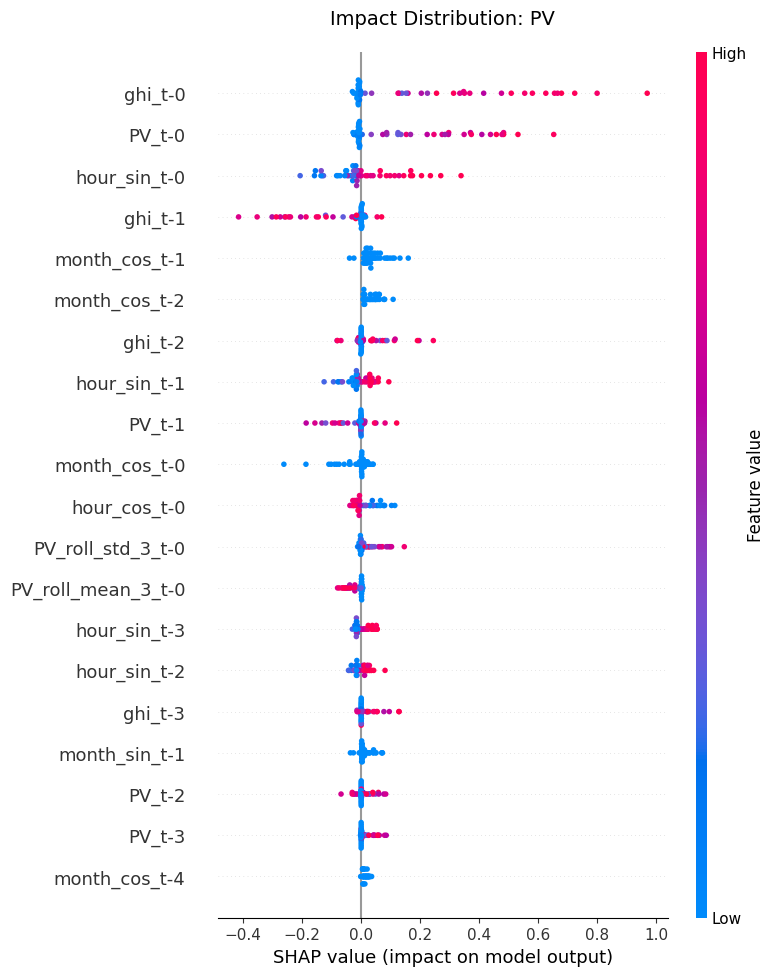

In [2]:

current_shap_raw = np.array(all_shap_dict[0])
s_flat, d_flat, names = get_flattened_data(current_shap_raw)
plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, show=False)
plt.title(f"Impact Distribution: PV", fontsize=14, pad=20)
plt.show()

### 2. Global Feature Importance
**What is this?** The mean absolute SHAP value for each feature.  
**What to focus on:** The length of the bar. It represents the "global" influence of a feature—how much it moves the prediction on average, regardless of direction.

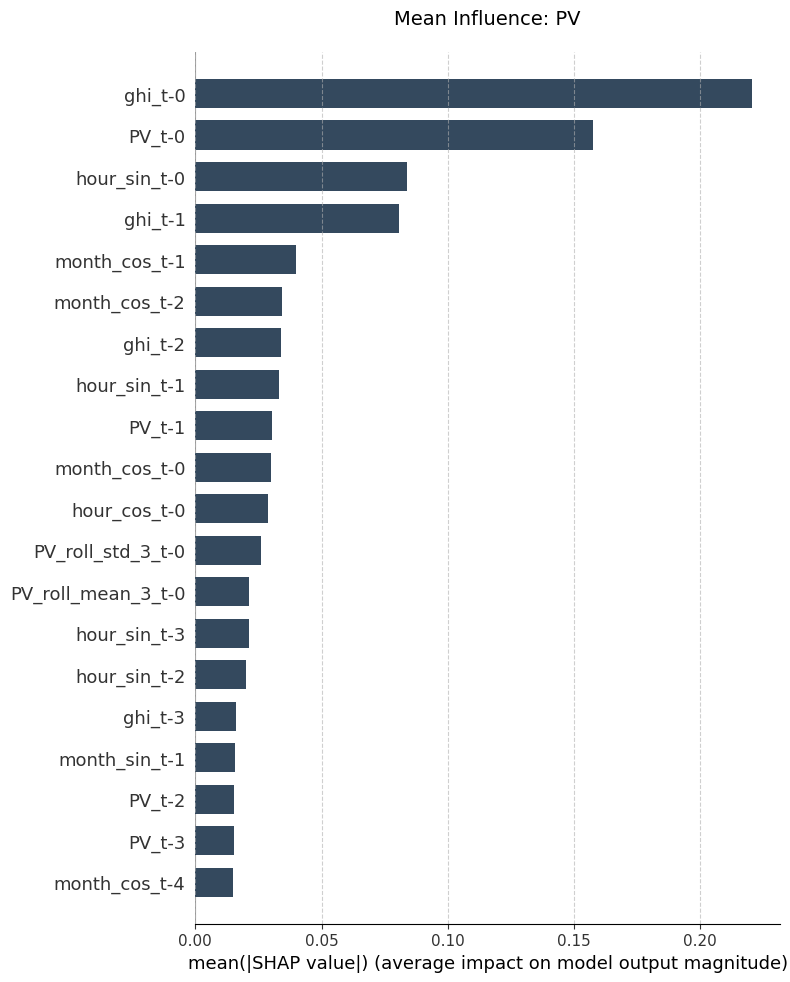

In [3]:

plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, plot_type='bar', show=False, color='#34495e')
plt.title(f"Mean Influence: PV", fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 3. Temporal Relevance
**What is this?** A look at which time-steps in the `6` window are most influential.  
**What to focus on:** Does the model care more about the immediate past (`t-0`, `t-1`) or older history? A peak at `t-0` suggests a reactive model; a peak at `t-5` suggests a dependency on long-term trends.

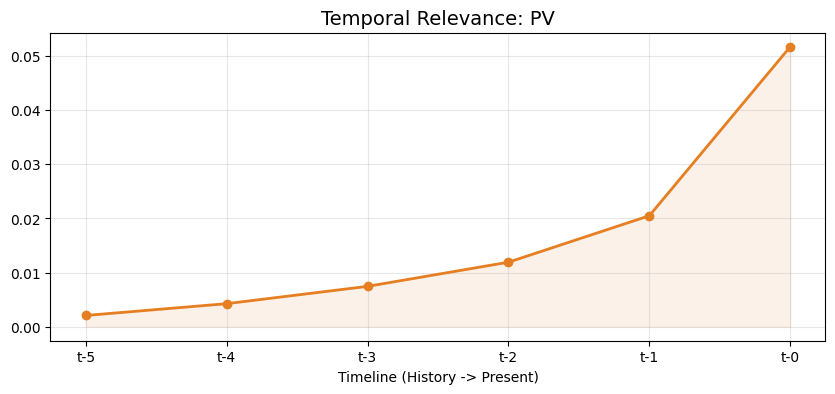

In [4]:

current_shap_raw = np.array(all_shap_dict[0])
importance_per_step = np.abs(current_shap_raw).mean(axis=(0, 2)).flatten()
time_labels = [f"t-{i}" for i in range(look_back-1, -1, -1)]
time_axis = list(range(len(time_labels)))

plt.figure(figsize=(10, 4))
plt.plot(time_axis, importance_per_step, marker='o', linewidth=2, color='#e67e22')
plt.xticks(time_axis, time_labels)
plt.title(f"Temporal Relevance: PV", fontsize=14)
plt.xlabel("Timeline (History -> Present)")
plt.fill_between(time_axis, importance_per_step, alpha=0.1, color='#e67e22')
plt.grid(True, alpha=0.3)
plt.show()

### 4. Focused View: Top 5 Drivers
**What is this?** A high-precision look at the five most critical variables for `PV`.  
**What to focus on:** The gap between the 1st and 5th feature. If the 1st is much larger, the model is heavily reliant on a single "smoking gun" variable.

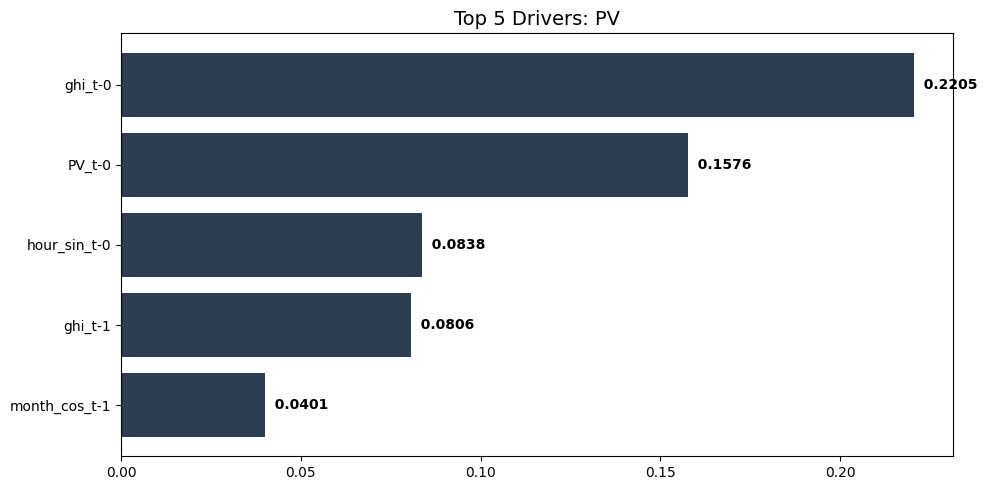

In [5]:

mean_shap = np.abs(s_flat).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[-5:]
plt.figure(figsize=(10, 5))
plt.barh([names[i] for i in sorted_idx], mean_shap[sorted_idx], color='#2c3e50')
plt.title(f"Top 5 Drivers: PV", fontsize=14)
for i, v in enumerate(mean_shap[sorted_idx]):
    plt.text(v, i, f"  {v:.4f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()